In [ ]:
# New Cell 1: Install SUMO from official PPA (fixes netconvert segfault)
import subprocess, os

# Remove the old broken apt version
subprocess.run(["apt-get", "remove", "-y", "sumo", "sumo-tools", "sumo-doc"],
               capture_output=True)

# Add the official SUMO PPA
cmds = [
    "add-apt-repository -y ppa:sumo/stable",
    "apt-get update -qq",
    "apt-get install -y sumo sumo-tools sumo-doc",
]
for cmd in cmds:
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"Failed: {cmd}\n{result.stderr}")
    else:
        print(f"{cmd.split()[0]}")

os.environ["SUMO_HOME"] = "/usr/share/sumo"
print("\nSUMO_HOME:", os.environ["SUMO_HOME"])

add-apt-repository
apt-get
apt-get

SUMO_HOME: /usr/share/sumo


In [ ]:
# Verify SUMO version — should be 1.19+ or higher
result = subprocess.run(["sumo", "--version"], capture_output=True, text=True)
print(result.stdout.split("\n")[0])

result2 = subprocess.run(["netconvert", "--version"], capture_output=True, text=True)
print(result2.stdout.split("\n")[0])

Eclipse SUMO sumo 1.26.0
Eclipse SUMO netconvert 1.26.0


In [ ]:
# Fix Cell A: Wipe and regenerate all SUMO config files from scratch
import os, subprocess, shutil

# Clean slate
if os.path.exists("sumo_config"):
    shutil.rmtree("sumo_config")
os.makedirs("sumo_config")

# --- Nodes ---
nodes_xml = """<?xml version="1.0" encoding="UTF-8"?>
<nodes>
    <node id="center" x="0"    y="0"    type="traffic_light"/>
    <node id="north"  x="0"    y="500"  type="priority"/>
    <node id="south"  x="0"    y="-500" type="priority"/>
    <node id="east"   x="500"  y="0"    type="priority"/>
    <node id="west"   x="-500" y="0"    type="priority"/>
</nodes>"""

# --- Edges (one lane only — avoids multi-lane connection complexity) ---
edges_xml = """<?xml version="1.0" encoding="UTF-8"?>
<edges>
    <edge id="N2C" from="north"  to="center" numLanes="1" speed="13.89"/>
    <edge id="S2C" from="south"  to="center" numLanes="1" speed="13.89"/>
    <edge id="E2C" from="east"   to="center" numLanes="1" speed="13.89"/>
    <edge id="W2C" from="west"   to="center" numLanes="1" speed="13.89"/>
    <edge id="C2N" from="center" to="north"  numLanes="1" speed="13.89"/>
    <edge id="C2S" from="center" to="south"  numLanes="1" speed="13.89"/>
    <edge id="C2E" from="center" to="east"   numLanes="1" speed="13.89"/>
    <edge id="C2W" from="center" to="west"   numLanes="1" speed="13.89"/>
</edges>"""

# --- Routes ---
routes_xml = """<?xml version="1.0" encoding="UTF-8"?>
<routes>
    <vType id="car" accel="2.6" decel="4.5" sigma="0.5" length="5" minGap="2.5" maxSpeed="13.89"/>
    <flow id="NS" type="car" from="N2C" to="C2S" begin="0" end="3600" vehsPerHour="300"/>
    <flow id="SN" type="car" from="S2C" to="C2N" begin="0" end="3600" vehsPerHour="300"/>
    <flow id="EW" type="car" from="E2C" to="C2W" begin="0" end="3600" vehsPerHour="200"/>
    <flow id="WE" type="car" from="W2C" to="C2E" begin="0" end="3600" vehsPerHour="200"/>
</routes>"""

# --- SUMO config ---
sumocfg_xml = """<?xml version="1.0" encoding="UTF-8"?>
<configuration>
    <input>
        <net-file value="intersection.net.xml"/>
        <route-files value="routes.rou.xml"/>
    </input>
    <time>
        <begin value="0"/>
        <end value="3600"/>
        <step-length value="1"/>
    </time>
</configuration>"""

with open("sumo_config/intersection.nod.xml", "w") as f: f.write(nodes_xml)
with open("sumo_config/intersection.edg.xml", "w") as f: f.write(edges_xml)
with open("sumo_config/routes.rou.xml",        "w") as f: f.write(routes_xml)
with open("sumo_config/intersection.sumocfg",  "w") as f: f.write(sumocfg_xml)

In [ ]:
# Fix Cell B (corrected): netconvert — ignore return code -11 (post-write segfault)
import os, subprocess

result = subprocess.run([
    "netconvert",
    "--node-files=sumo_config/intersection.nod.xml",
    "--edge-files=sumo_config/intersection.edg.xml",
    "--output-file=sumo_config/intersection.net.xml",
    "--tls.guess=true",
    "--tls.guess-signals=true",
    "--no-warnings",
], capture_output=True, text=True)

print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Return code:", result.returncode, "(−11 = known Colab segfault bug, safe to ignore if file exists)")

net_path = "sumo_config/intersection.net.xml"
assert os.path.exists(net_path), "net.xml was not created at all!"

size = os.path.getsize(net_path)
assert size > 5000, f"net.xml too small ({size} bytes) — likely corrupt"

print(f"\nnet.xml exists and is valid — {size} bytes. Proceeding!!")

STDOUT: Success.

STDERR: 
Return code: -11 (−11 = known Colab segfault bug, safe to ignore if file exists)

net.xml exists and is valid — 17447 bytes. Proceeding!!


In [ ]:
# Fix Cell C: Validate the full config with a short dry-run
result = subprocess.run([
    "sumo",
    "-c", "sumo_config/intersection.sumocfg",
    "--no-step-log",
    "--end", "50",
], capture_output=True, text=True)

print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Return code:", result.returncode)

assert result.returncode == 0, "SUMO dry-run failed — see STDERR above"
print("Dry-run passed!")

STDOUT: 
STDERR: 
Return code: 0
Dry-run passed!


In [ ]:
# Fix Cell D (corrected): Inspect TLS and connection count
import sys, os
sys.path.append(os.path.join(os.environ["SUMO_HOME"], "tools"))
import sumolib

net = sumolib.net.readNet("sumo_config/intersection.net.xml")

# --- TLS phases ---
tls_list = net.getTrafficLights()
for tls in tls_list:
    print(f"TLS id: {tls.getID()}")
    for prog_id, prog in tls.getPrograms().items():
        phases = prog.getPhases()
        print(f"  Program: {prog_id}  |  Phases: {len(phases)}")
        for i, phase in enumerate(phases):
            print(f"    Phase {i}: duration={phase.duration}  state='{phase.state}'")
        if phases:
            print(f"  → State string length: {len(phases[0].state)}")
        else:
            print("  → No phases defined (netconvert left it empty)")

# --- Count controlled connections (= required state string length) ---
print("\n--- Controlled connections per TLS ---")
for tls in tls_list:
    connections = tls.getConnections()
    print(f"TLS '{tls.getID()}': {len(connections)} controlled connections")
    print(f"  → You need a phase state string of length: {len(connections)}")

TLS id: center

--- Controlled connections per TLS ---
TLS 'center': 16 controlled connections
  → You need a phase state string of length: 16


In [ ]:
# Fix Cell E: Print all 16 connections so we can build correct phase strings
import sys, os
sys.path.append(os.path.join(os.environ["SUMO_HOME"], "tools"))
import sumolib

net = sumolib.net.readNet("sumo_config/intersection.net.xml")
tls = net.getTrafficLights()[0]

print(f"TLS: {tls.getID()} — {len(tls.getConnections())} connections\n")
print(f"{'Idx':>4}  {'From Edge':<10} {'→'} {'To Edge':<10} {'FromLane':>9} {'ToLane':>7}")
print("-" * 55)
for idx, (from_lane, to_lane, _) in enumerate(tls.getConnections()):
    from_edge = from_lane.getEdge().getID()
    to_edge   = to_lane.getEdge().getID()
    print(f"{idx:>4}  {from_edge:<10} →  {to_edge:<10} lane {from_lane.getIndex():>2} → {to_lane.getIndex():>2}")

TLS: center — 16 connections

 Idx  From Edge  → To Edge     FromLane  ToLane
-------------------------------------------------------
   0  E2C        →  C2N        lane  0 →  0
   1  E2C        →  C2W        lane  0 →  0
   2  E2C        →  C2S        lane  0 →  0
   3  E2C        →  C2E        lane  0 →  0
   4  N2C        →  C2W        lane  0 →  0
   5  N2C        →  C2S        lane  0 →  0
   6  N2C        →  C2E        lane  0 →  0
   7  N2C        →  C2N        lane  0 →  0
   8  S2C        →  C2E        lane  0 →  0
   9  S2C        →  C2N        lane  0 →  0
  10  S2C        →  C2W        lane  0 →  0
  11  S2C        →  C2S        lane  0 →  0
  12  W2C        →  C2S        lane  0 →  0
  13  W2C        →  C2E        lane  0 →  0
  14  W2C        →  C2N        lane  0 →  0
  15  W2C        →  C2W        lane  0 →  0


In [ ]:
# Kill Cell: Nuke all stale SUMO/TraCI processes and free the port
import subprocess, time

subprocess.run(["pkill", "-9", "-f", "sumo"], capture_output=True)
subprocess.run(["fuser", "-k", "8813/tcp"], capture_output=True)
time.sleep(1)

# Verify port is free
result = subprocess.run(["fuser", "8813/tcp"], capture_output=True, text=True)
if result.stdout.strip():
    print("Port 8813 still in use — try restarting the Colab runtime")
else:
    print("Port 8813 is free.")

Port 8813 is free.


In [ ]:
# Cell F (updated): Environment with finer state binning
import traci
import subprocess, time, os, socket
import numpy as np

NS_GREEN  = "GGGGrrrrGGGGrrrr"
NS_YELLOW = "yyyyrrrryyyyrrrr"
EW_GREEN  = "rrrrGGGGrrrrGGGG"
EW_YELLOW = "rrrryyyyrrrryyyy"

def get_free_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("", 0))
        s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        return s.getsockname()[1]

class SumoIntersectionEnv:
    """
    State  : (ns_queue_bin, ew_queue_bin, current_phase)
             ns_queue = N2C + S2C halting vehicles, binned 0-9
             ew_queue = E2C + W2C halting vehicles, binned 0-9
             current_phase = 0 or 1
             → 10 x 10 x 2 = 200 possible states (much richer)
    Actions: 0 = NS green | 1 = EW green
    Reward : negative total vehicle waiting time
    """

    PHASES = {
        0: (NS_GREEN,  NS_YELLOW),
        1: (EW_GREEN,  EW_YELLOW),
    }
    YELLOW_DURATION = 4
    MIN_GREEN       = 10
    MAX_STEPS       = 3600
    BIN_SIZE        = 2    # vehicles per bin (was 5 before — finer now)
    MAX_BIN         = 9

    def __init__(self, cfg_path="sumo_config/intersection.sumocfg", gui=False):
        self.cfg_path       = os.path.abspath(cfg_path)
        self.gui            = gui
        self.sumo_binary    = "sumo-gui" if gui else "sumo"
        self.tls_id         = "center"
        self.incoming_edges = ["N2C", "S2C", "E2C", "W2C"]
        self.current_step   = 0
        self.current_phase  = 0
        self._sumo_running  = False
        self._sumo_proc     = None

    def reset(self):
        self._safe_close()
        port = get_free_port()
        self._port = port

        cmd = [
            self.sumo_binary,
            "-c", self.cfg_path,
            "--no-step-log",
            "--no-warnings",
            "--random",
            "--quit-on-end",
            "--remote-port", str(port),
        ]

        self._sumo_proc = subprocess.Popen(
            cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE
        )
        time.sleep(1.0)

        if self._sumo_proc.poll() is not None:
            err = self._sumo_proc.stderr.read().decode()
            raise RuntimeError(f"SUMO crashed on startup:\n{err}")

        try:
            traci.init(port=port, numRetries=10)
        except Exception as e:
            err = self._sumo_proc.stderr.read().decode()
            self._sumo_proc.kill()
            raise RuntimeError(f"TraCI connection failed on port {port}: {e}\nSUMO stderr:\n{err}")

        self._sumo_running = True
        self.current_step  = 0
        self.current_phase = 0

        actual_state = traci.trafficlight.getRedYellowGreenState(self.tls_id)
        if len(actual_state) != 16:
            self._safe_close()
            raise RuntimeError(f"Phase string length mismatch! Got {len(actual_state)}: '{actual_state}'")

        traci.trafficlight.setRedYellowGreenState(self.tls_id, self.PHASES[0][0])
        return self._get_state()

    def step(self, action):
        if action != self.current_phase:
            yellow = self.PHASES[self.current_phase][1]
            traci.trafficlight.setRedYellowGreenState(self.tls_id, yellow)
            for _ in range(self.YELLOW_DURATION):
                traci.simulationStep()
                self.current_step += 1

        traci.trafficlight.setRedYellowGreenState(self.tls_id, self.PHASES[action][0])
        self.current_phase = action

        total_reward = 0
        for _ in range(self.MIN_GREEN):
            traci.simulationStep()
            self.current_step += 1
            total_reward -= self._get_total_waiting_time()

        return self._get_state(), total_reward, self.current_step >= self.MAX_STEPS

    def _safe_close(self):
        if self._sumo_running:
            try:
                traci.close()
            except Exception:
                pass
            self._sumo_running = False
        if self._sumo_proc is not None:
            try:
                self._sumo_proc.kill()
                self._sumo_proc.wait()
            except Exception:
                pass
            self._sumo_proc = None
        subprocess.run(["pkill", "-9", "-f", "sumo"], capture_output=True)
        time.sleep(0.5)

    def close(self):
        self._safe_close()

    def _get_total_waiting_time(self):
        return sum(traci.edge.getWaitingTime(e) for e in self.incoming_edges)

    def _get_state(self):
        # Aggregate N+S queues and E+W queues separately
        ns_queue = (traci.edge.getLastStepHaltingNumber("N2C") +
                    traci.edge.getLastStepHaltingNumber("S2C"))
        ew_queue = (traci.edge.getLastStepHaltingNumber("E2C") +
                    traci.edge.getLastStepHaltingNumber("W2C"))

        ns_bin = min(int(ns_queue / self.BIN_SIZE), self.MAX_BIN)
        ew_bin = min(int(ew_queue / self.BIN_SIZE), self.MAX_BIN)

        # Include current phase in state so agent knows what's active
        return (ns_bin, ew_bin, self.current_phase)

    @property
    def n_actions(self): return 2

print("Updated SumoIntersectionEnv:")
print("State space : ns_bin(0-9) × ew_bin(0-9) × phase(0-1) = 200 states")
print("Bin size    : 2 vehicles per bin (finer than before)")

Updated SumoIntersectionEnv:
State space : ns_bin(0-9) × ew_bin(0-9) × phase(0-1) = 200 states
Bin size    : 2 vehicles per bin (finer than before)


In [ ]:
# Fix Cell G: Single episode smoke test — catches phase string errors early
print("Running smoke test (50 steps)...")

env = SumoIntersectionEnv(cfg_path="sumo_config/intersection.sumocfg")

try:
    state = env.reset()
    print(f"reset() OK — initial state: {state}")

    for i in range(5):
        action = i % 2
        next_state, reward, done = env.step(action)
        print(f"  step {i+1}: action={action}  reward={reward:.1f}  state={next_state}  done={done}")
        if done:
            break

    print("Smoke test passed!")

except RuntimeError as e:
    print(f"Smoke test failed:\n{e}")
finally:
    env.close()

Running smoke test (50 steps)...
reset() OK — initial state: (0, 0, 0)
  step 1: action=0  reward=0.0  state=(0, 0, 0)  done=False
  step 2: action=1  reward=0.0  state=(0, 0, 1)  done=False
  step 3: action=0  reward=0.0  state=(0, 0, 0)  done=False
  step 4: action=1  reward=-56.0  state=(1, 0, 1)  done=False
  step 5: action=0  reward=-11.0  state=(0, 1, 0)  done=False
Smoke test passed!


In [ ]:
# Cell 7 (updated): Q-Learning Agent with per-episode stats
import numpy as np

class QLearningAgent:
    def __init__(self,
                 n_actions     = 2,
                 alpha         = 0.1,
                 gamma         = 0.95,
                 epsilon       = 1.0,
                 epsilon_min   = 0.05,
                 epsilon_decay = 0.990):   # slower decay → more exploration

        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_table       = {}

    def _get_q(self, state):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.n_actions)
        return self.q_table[state]

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self._get_q(state)))

    def learn(self, state, action, reward, next_state):
        q_current = self._get_q(state)[action]
        q_next    = np.max(self._get_q(next_state))
        self._get_q(state)[action] += self.alpha * (reward + self.gamma * q_next - q_current)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def stats(self):
        return {
            "q_table_states": len(self.q_table),
            "epsilon":        round(self.epsilon, 4)
        }

print("QLearningAgent defined.")

QLearningAgent defined.


In [ ]:
# Cell 8 (updated): Training with baseline comparison
import time

N_EPISODES = 300   # more episodes so epsilon decays further

# --- Fixed baseline: always NS green (action 0) ---
print("Running fixed-policy baseline (10 episodes)...")
baseline_env     = SumoIntersectionEnv()
baseline_rewards = []

for _ in range(10):
    state = baseline_env.reset()
    total, done = 0, False
    while not done:
        state, reward, done = baseline_env.step(0)   # always NS green
        total += reward
    baseline_rewards.append(total)

baseline_env.close()
baseline_mean = np.mean(baseline_rewards)
print(f"Baseline mean reward: {baseline_mean:.1f}\n")

# --- Q-Learning training ---
env   = SumoIntersectionEnv()
agent = QLearningAgent(n_actions=env.n_actions)
episode_rewards = []

print(f"{'Ep':>4} | {'Total Reward':>13} | {'vs Baseline':>12} | {'Steps':>6} | {'ε':>6} | {'Q-States':>9} | {'Time(s)':>8}")
print("-" * 80)

for ep in range(1, N_EPISODES + 1):
    t0 = time.time()
    try:
        state        = env.reset()
        total_reward = 0
        done         = False
        steps        = 0

        while not done:
            action                   = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.learn(state, action, reward, next_state)
            state         = next_state
            total_reward += reward
            steps        += 1

        agent.decay_epsilon()
        elapsed = time.time() - t0
        episode_rewards.append(total_reward)

        vs_base = total_reward - baseline_mean
        marker  = "↑" if vs_base > 0 else " "
        stats   = agent.stats()
        print(f"{ep:>4} | {total_reward:>13.1f} | {vs_base:>+12.1f}{marker} | {steps:>6} | "
              f"{stats['epsilon']:>6.4f} | {stats['q_table_states']:>9} | {elapsed:>7.1f}s")

    except Exception as e:
        print(f"{ep:>4} | Episode failed: {e}")
        env._safe_close()
        time.sleep(1)
        continue

env.close()
print(f"\nTraining complete.")
print(f"   Best episode  : {max(episode_rewards):.1f}")
print(f"   Final 10 avg  : {np.mean(episode_rewards[-10:]):.1f}")
print(f"   Baseline avg  : {baseline_mean:.1f}")
print(f"   Improvement   : {np.mean(episode_rewards[-10:]) - baseline_mean:+.1f}")

Running fixed-policy baseline (10 episodes)...
Baseline mean reward: -51289218.8

  Ep |  Total Reward |  vs Baseline |  Steps |      ε |  Q-States |  Time(s)
--------------------------------------------------------------------------------
   1 |     -163393.0 |  +51125825.8↑ |    306 | 0.9900 |        17 |     3.3s
   2 |      -74781.0 |  +51214437.8↑ |    297 | 0.9801 |        17 |     3.0s
   3 |      -53628.0 |  +51235590.8↑ |    290 | 0.9703 |        17 |     3.3s
   4 |     -121788.0 |  +51167430.8↑ |    300 | 0.9606 |        17 |     3.3s
   5 |      -93231.0 |  +51195987.8↑ |    302 | 0.9510 |        17 |     3.3s
   6 |      -50397.0 |  +51238821.8↑ |    289 | 0.9415 |        17 |     3.0s
   7 |     -113298.0 |  +51175920.8↑ |    300 | 0.9321 |        18 |     3.3s
   8 |      -85709.0 |  +51203509.8↑ |    299 | 0.9227 |        18 |     3.3s
   9 |      -79245.0 |  +51209973.8↑ |    294 | 0.9135 |        18 |     3.3s
  10 |      -82721.0 |  +51206497.8↑ |    297 | 0.9044 |  

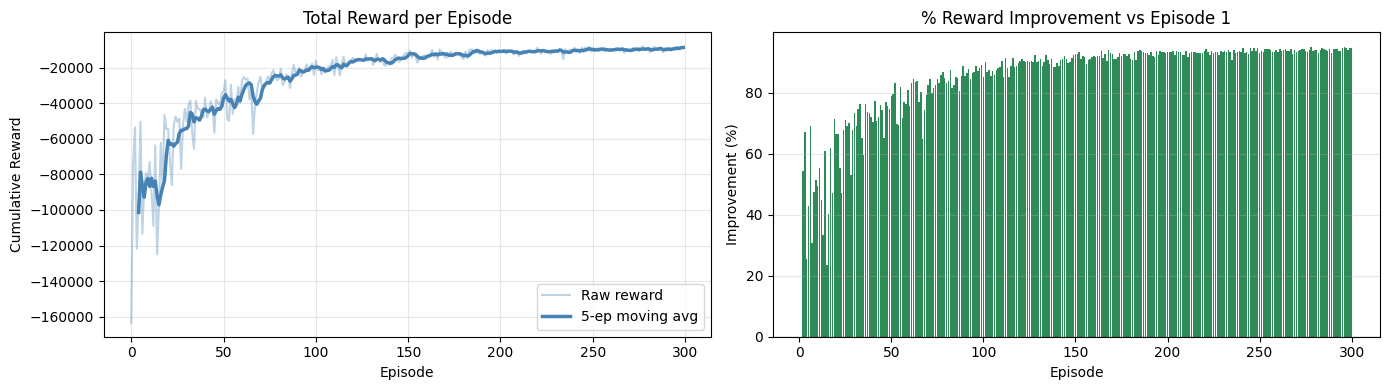

✅ Plot saved to training_results.png


In [ ]:
# Cell 9: Plot reward curve
import matplotlib.pyplot as plt
import numpy as np

window   = 5
rewards  = np.array(episode_rewards)
smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: reward curve with smoothing
axes[0].plot(rewards, alpha=0.35, color='steelblue', label='Raw reward')
axes[0].plot(range(window - 1, len(rewards)), smoothed,
             color='steelblue', lw=2.5, label=f'{window}-ep moving avg')
axes[0].set_title("Total Reward per Episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Cumulative Reward")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: improvement over baseline (episode 1)
baseline = rewards[0]
pct_improvement = (rewards - baseline) / abs(baseline) * 100
axes[1].bar(range(1, len(rewards) + 1), pct_improvement,
            color=['tomato' if v < 0 else 'seagreen' for v in pct_improvement])
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title("% Reward Improvement vs Episode 1")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Improvement (%)")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("training_results.png", dpi=150)
plt.show()
print("✅ Plot saved to training_results.png")

In [ ]:
# Cell 10: Comprehensive evaluation — Q-agent vs Fixed NS vs Fixed EW vs Random
import numpy as np
import time

N_EVAL = 20   # episodes per policy

def run_policy(policy_fn, label, n_episodes=N_EVAL):
    """Run any policy function for n_episodes, return list of rewards."""
    env    = SumoIntersectionEnv()
    totals = []
    for ep in range(n_episodes):
        state = env.reset()
        total, done = 0, False
        while not done:
            action         = policy_fn(state)
            state, r, done = env.step(action)
            total         += r
        totals.append(total)
        print(f"  [{label}] ep {ep+1:>2}/{n_episodes}  reward={total:.0f}")
    env.close()
    return totals

print("=" * 55)
print("  Evaluating 4 policies...")
print("=" * 55)

# 1. Trained Q-agent (greedy)
agent.epsilon = 0.0
q_rewards = run_policy(agent.choose_action, "Q-Agent ")

# 2. Fixed NS green always
ns_rewards = run_policy(lambda s: 0, "Fixed-NS")

# 3. Fixed EW green always
ew_rewards = run_policy(lambda s: 1, "Fixed-EW")

# 4. Random policy
rng_rewards = run_policy(lambda s: np.random.randint(2), "Random  ")

# Summary
policies = {
    "Q-Learning Agent" : q_rewards,
    "Fixed NS Green"   : ns_rewards,
    "Fixed EW Green"   : ew_rewards,
    "Random Policy"    : rng_rewards,
}

print("\n" + "=" * 60)
print(f"  {'Policy':<22} {'Mean':>12} {'Std':>10} {'Best':>12}")
print("=" * 60)
for name, rewards in policies.items():
    print(f"  {name:<22} {np.mean(rewards):>12.1f} "
          f"{np.std(rewards):>10.1f} {np.max(rewards):>12.1f}")
print("=" * 60)

q_mean  = np.mean(q_rewards)
ns_mean = np.mean(ns_rewards)
print(f"\n  Q-Agent improvement over Fixed-NS: "
      f"{(q_mean - ns_mean)/abs(ns_mean)*100:.2f}%")

  Evaluating 4 policies...
  [Q-Agent ] ep  1/20  reward=-7888
  [Q-Agent ] ep  2/20  reward=-8643
  [Q-Agent ] ep  3/20  reward=-7845
  [Q-Agent ] ep  4/20  reward=-9682
  [Q-Agent ] ep  5/20  reward=-8983
  [Q-Agent ] ep  6/20  reward=-8729
  [Q-Agent ] ep  7/20  reward=-9005
  [Q-Agent ] ep  8/20  reward=-7905
  [Q-Agent ] ep  9/20  reward=-8389
  [Q-Agent ] ep 10/20  reward=-8740
  [Q-Agent ] ep 11/20  reward=-8675
  [Q-Agent ] ep 12/20  reward=-8298
  [Q-Agent ] ep 13/20  reward=-8239
  [Q-Agent ] ep 14/20  reward=-9119
  [Q-Agent ] ep 15/20  reward=-9270
  [Q-Agent ] ep 16/20  reward=-8570
  [Q-Agent ] ep 17/20  reward=-8272
  [Q-Agent ] ep 18/20  reward=-7781
  [Q-Agent ] ep 19/20  reward=-9091
  [Q-Agent ] ep 20/20  reward=-9085
  [Fixed-NS] ep  1/20  reward=-51274989
  [Fixed-NS] ep  2/20  reward=-51289362
  [Fixed-NS] ep  3/20  reward=-51250748
  [Fixed-NS] ep  4/20  reward=-51244846
  [Fixed-NS] ep  5/20  reward=-51313846
  [Fixed-NS] ep  6/20  reward=-51287778
  [Fixed-NS] 

/tmp/ipykernel_2035/1411682015.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(names, rotation=15, ha='right', fontsize=9)


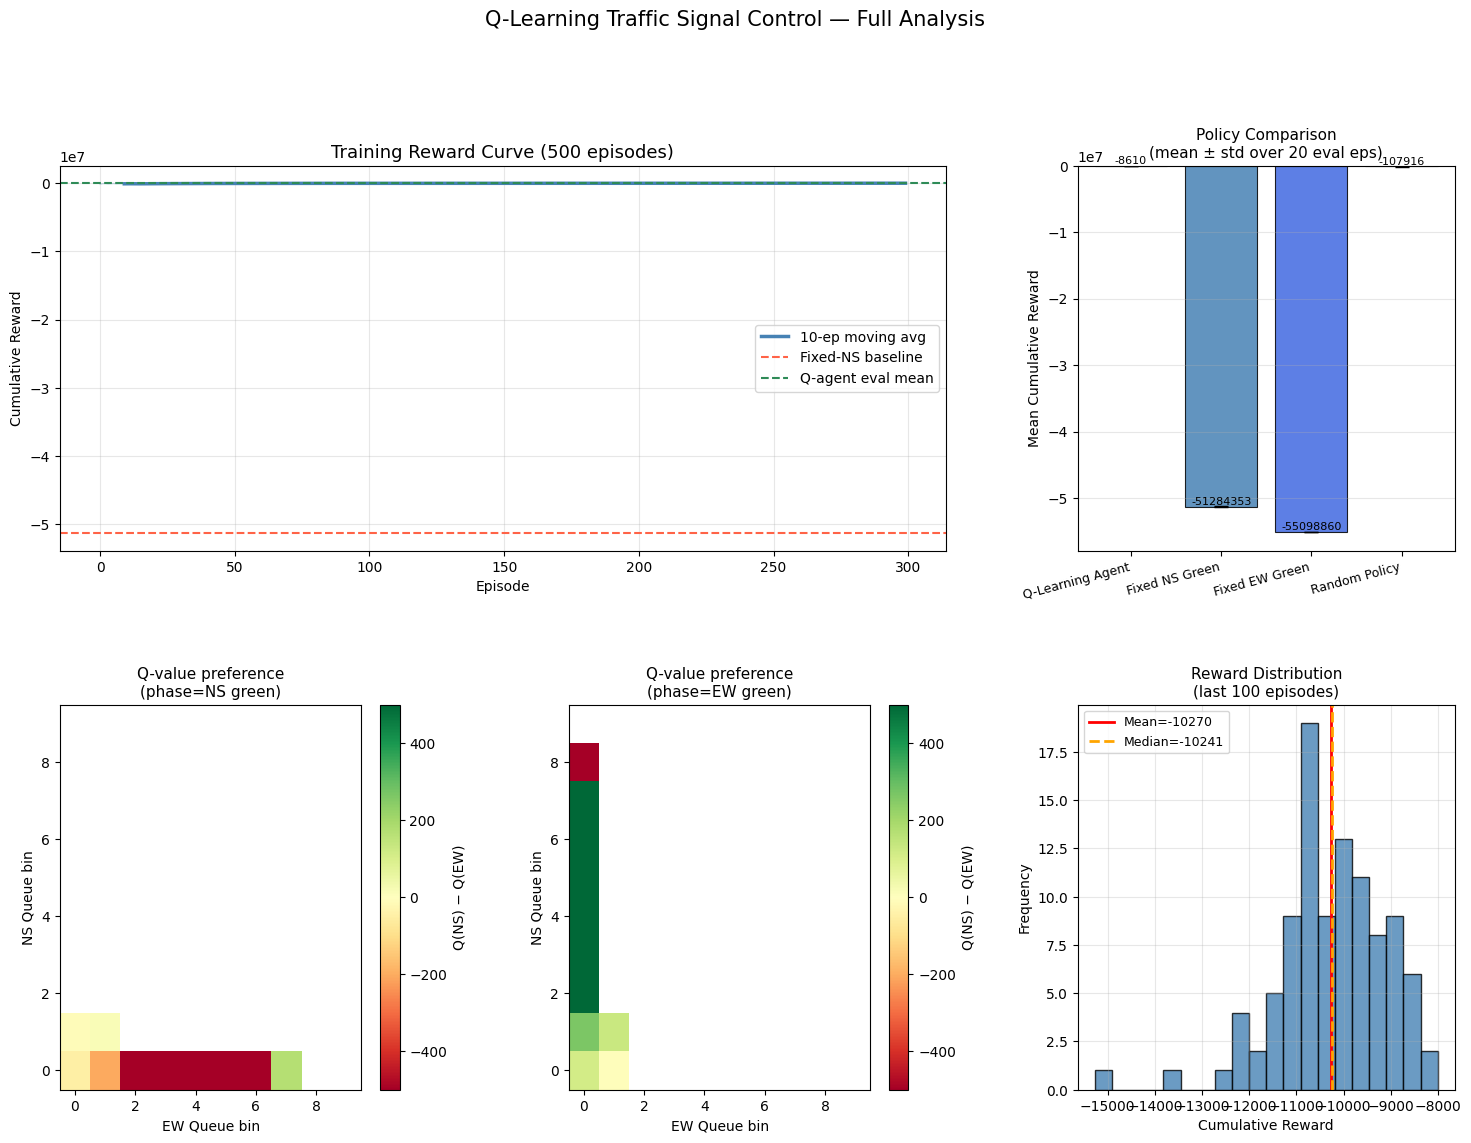

✅ Full analysis plot saved to full_analysis.png


In [ ]:
# Cell 11: Full analysis — training curve + policy comparison + Q-table heatmap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

rewards  = np.array(episode_rewards)
window   = 10
smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')

# ── Plot 1: Training curve ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(rewards, alpha=0.25, color='steelblue', lw=1)
ax1.plot(range(window - 1, len(rewards)), smoothed,
         color='steelblue', lw=2.5, label=f'{window}-ep moving avg')
ax1.axhline(np.mean(ns_rewards), color='tomato', lw=1.5,
            linestyle='--', label='Fixed-NS baseline')
ax1.axhline(np.mean(q_rewards),  color='seagreen', lw=1.5,
            linestyle='--', label='Q-agent eval mean')
ax1.set_title("Training Reward Curve (500 episodes)", fontsize=13)
ax1.set_xlabel("Episode")
ax1.set_ylabel("Cumulative Reward")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Plot 2: Policy comparison bar chart ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
names  = list(policies.keys())
means  = [np.mean(v) for v in policies.values()]
stds   = [np.std(v)  for v in policies.values()]
colors = ['seagreen', 'steelblue', 'royalblue', 'tomato']
bars   = ax2.bar(names, means, yerr=stds, capsize=5,
                 color=colors, alpha=0.85, edgecolor='black', lw=0.8)
ax2.set_title("Policy Comparison\n(mean ± std over 20 eval eps)", fontsize=11)
ax2.set_ylabel("Mean Cumulative Reward")
ax2.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
for bar, mean in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{mean:.0f}', ha='center', va='bottom', fontsize=8)

# ── Plot 3: Q-table heatmap (phase=0, NS green) ──────────────────────
ax3 = fig.add_subplot(gs[1, 0])
q_grid_0 = np.full((10, 10), np.nan)
for (ns, ew, ph), q_vals in agent.q_table.items():
    if ph == 0:
        q_grid_0[ns, ew] = q_vals[0] - q_vals[1]   # preference for NS over EW

im3 = ax3.imshow(q_grid_0, cmap='RdYlGn', aspect='auto',
                 vmin=-500, vmax=500, origin='lower')
plt.colorbar(im3, ax=ax3, label='Q(NS) − Q(EW)')
ax3.set_title("Q-value preference\n(phase=NS green)", fontsize=11)
ax3.set_xlabel("EW Queue bin")
ax3.set_ylabel("NS Queue bin")

# ── Plot 4: Q-table heatmap (phase=1, EW green) ──────────────────────
ax4 = fig.add_subplot(gs[1, 1])
q_grid_1 = np.full((10, 10), np.nan)
for (ns, ew, ph), q_vals in agent.q_table.items():
    if ph == 1:
        q_grid_1[ns, ew] = q_vals[0] - q_vals[1]

im4 = ax4.imshow(q_grid_1, cmap='RdYlGn', aspect='auto',
                 vmin=-500, vmax=500, origin='lower')
plt.colorbar(im4, ax=ax4, label='Q(NS) − Q(EW)')
ax4.set_title("Q-value preference\n(phase=EW green)", fontsize=11)
ax4.set_xlabel("EW Queue bin")
ax4.set_ylabel("NS Queue bin")

# ── Plot 5: Reward distribution (last 100 eps) ───────────────────────
ax5 = fig.add_subplot(gs[1, 2])
last100 = rewards[-100:]
ax5.hist(last100, bins=20, color='steelblue', alpha=0.8, edgecolor='black', lw=0.5)
ax5.axvline(np.mean(last100), color='red', lw=2, label=f'Mean={np.mean(last100):.0f}')
ax5.axvline(np.median(last100), color='orange', lw=2,
            linestyle='--', label=f'Median={np.median(last100):.0f}')
ax5.set_title("Reward Distribution\n(last 100 episodes)", fontsize=11)
ax5.set_xlabel("Cumulative Reward")
ax5.set_ylabel("Frequency")
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

plt.suptitle("Q-Learning Traffic Signal Control — Full Analysis", fontsize=15, y=1.01)
plt.savefig("full_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Full analysis plot saved to full_analysis.png")

In [ ]:
# Cell 12: Print the full learned Q-table in a readable format
print("LEARNED Q-TABLE")
print("State: (NS_queue_bin, EW_queue_bin, current_phase)")
print("Action: 0=NS green, 1=EW green\n")
print(f"{'State':<28} {'Q(NS)':>10} {'Q(EW)':>10} {'Policy':>10}")
print("-" * 62)

phase_names = {0: "NS-green", 1: "EW-green"}
action_names = {0: "→ NS green", 1: "→ EW green"}

for state in sorted(agent.q_table.keys()):
    ns_bin, ew_bin, phase = state
    q_vals  = agent.q_table[state]
    best    = int(np.argmax(q_vals))
    state_str = f"NS={ns_bin} EW={ew_bin} phase={phase_names[phase]}"
    print(f"  {state_str:<26} {q_vals[0]:>10.1f} {q_vals[1]:>10.1f} {action_names[best]:>10}")

print(f"\nTotal states learned: {len(agent.q_table)}")

LEARNED Q-TABLE
State: (NS_queue_bin, EW_queue_bin, current_phase)
Action: 0=NS green, 1=EW green

State                             Q(NS)      Q(EW)     Policy
--------------------------------------------------------------
  NS=0 EW=0 phase=NS-green       -678.8     -631.5 → EW green
  NS=0 EW=0 phase=EW-green       -610.6     -723.8 → NS green
  NS=0 EW=1 phase=NS-green       -822.3     -616.0 → EW green
  NS=0 EW=1 phase=EW-green        -63.4      -57.8 → EW green
  NS=0 EW=2 phase=NS-green      -1324.6     -666.3 → EW green
  NS=0 EW=3 phase=NS-green      -2556.5     -759.7 → EW green
  NS=0 EW=4 phase=NS-green      -3204.4     -838.5 → EW green
  NS=0 EW=5 phase=NS-green      -1441.5     -604.0 → EW green
  NS=0 EW=6 phase=NS-green       -689.6        0.0 → EW green
  NS=0 EW=7 phase=NS-green          0.0     -168.0 → NS green
  NS=1 EW=0 phase=NS-green       -330.5     -321.2 → EW green
  NS=1 EW=0 phase=EW-green       -620.5     -883.6 → NS green
  NS=1 EW=1 phase=NS-green      


  Evaluating: Q-Learning Agent
   Ep      Reward   AvgWait   AvgQueue  Throughput    CO2(kg)   AvgTravel
  ---------------------------------------------------------------------------
    1       -8121      5.53       1.31         979   196.1222       90.07
    2       -8678      5.86       1.36         980   196.7351       90.31
    3       -8448      5.73       1.35         980   196.8245       90.31
    4       -8685      5.90       1.38         976   197.1970       90.84
    5       -8314      5.58       1.31         981   196.3357       90.02
    6       -7632      5.31       1.29         980   196.1360       89.89
    7       -7935      5.55       1.34         980   196.3993       90.49
    8       -7721      5.37       1.30         982   195.7312       90.17
    9       -8202      5.58       1.32         979   195.9313       90.02
   10       -8962      5.98       1.38         981   196.2479       90.68

  Evaluating: Fixed-NS Baseline
   Ep      Reward   AvgWait   AvgQueue  Thr

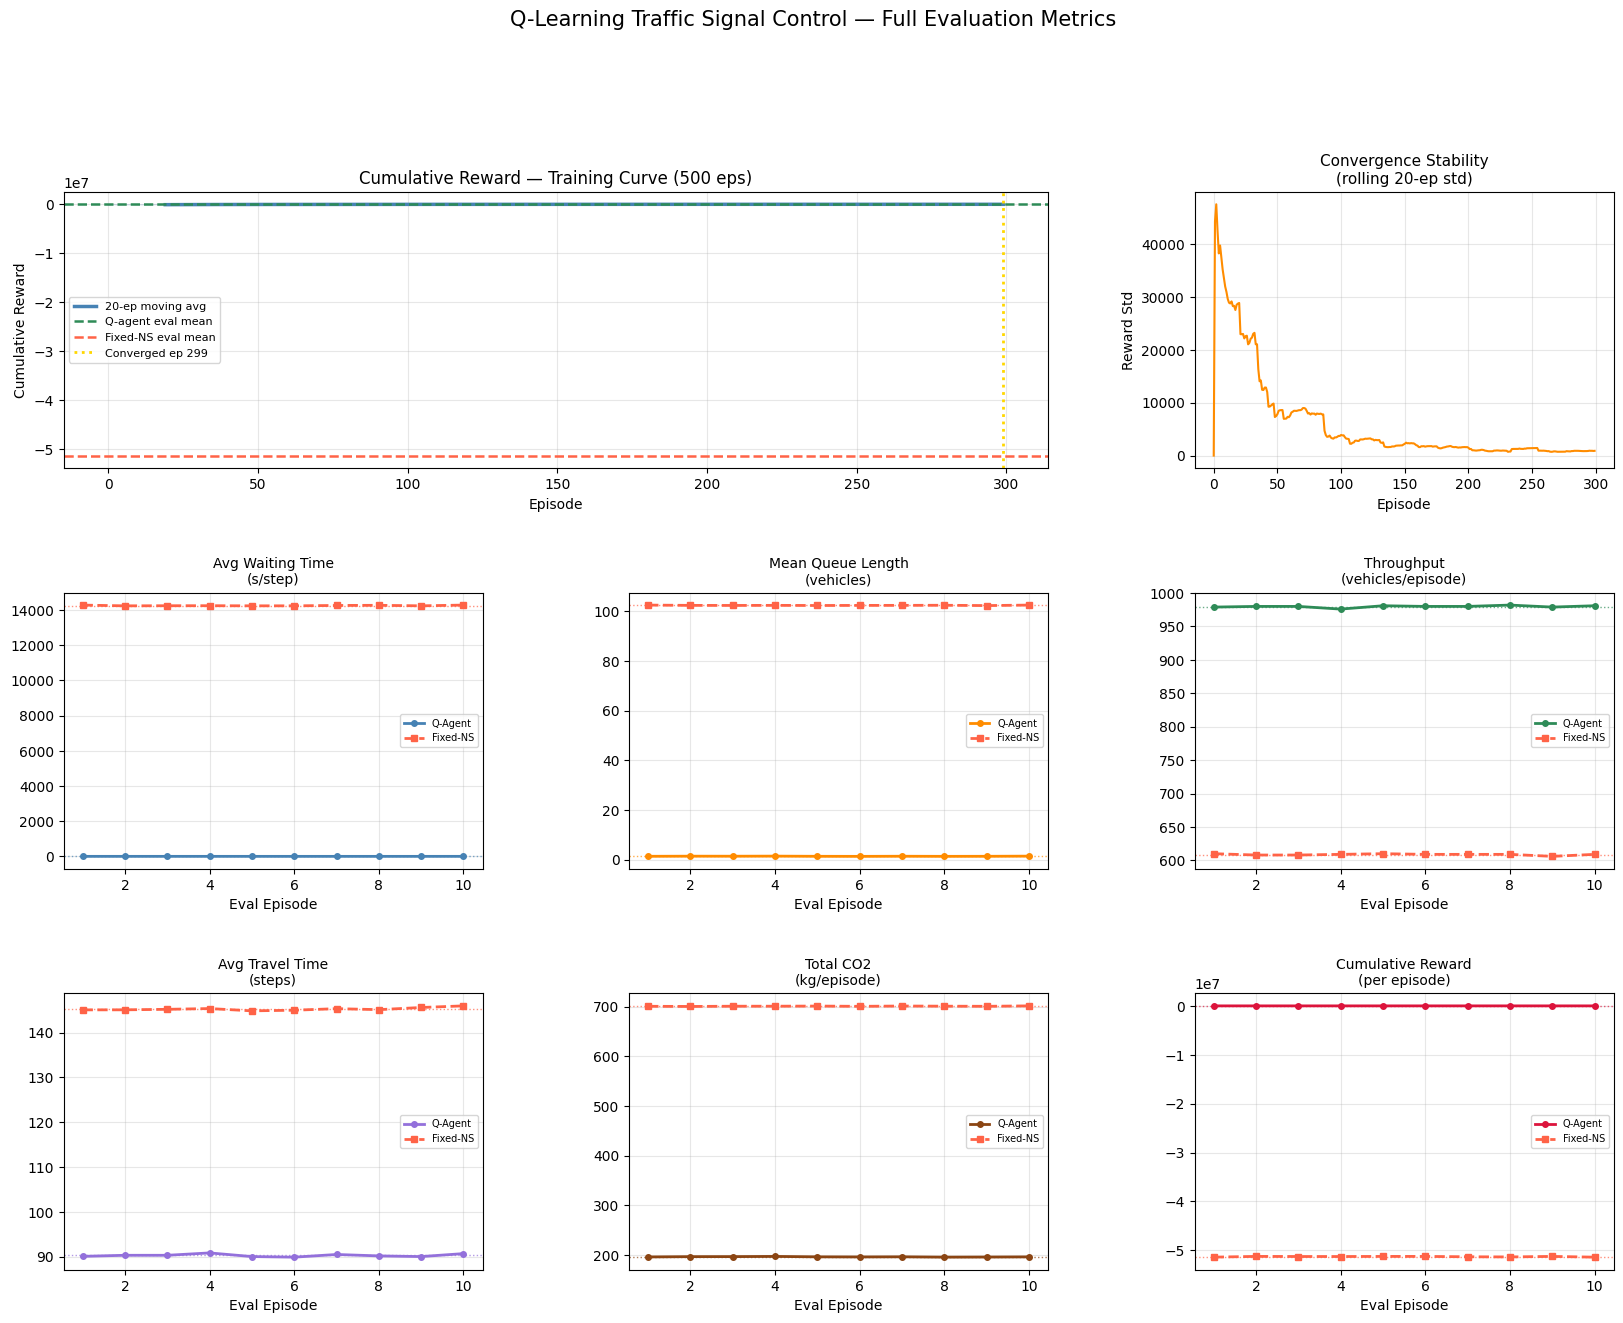

✅ Evaluation metrics plot saved to evaluation_metrics.png
✅ All metrics saved to evaluation_metrics.json


In [ ]:
# Evaluation Metrics Cell: Comprehensive RL Traffic Signal Metrics

import numpy as np
import traci
import subprocess, time, os, socket, json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

def get_free_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("", 0))
        s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        return s.getsockname()[1]

# ─────────────────────────────────────────────
# METRIC COLLECTOR
# ─────────────────────────────────────────────
class MetricCollector:
    """Collects per-step SUMO metrics during an episode."""

    def __init__(self, incoming_edges, all_edges):
        self.incoming_edges = incoming_edges
        self.all_edges      = all_edges
        self.reset()

    def reset(self):
        self.waiting_times   = []   # total waiting time per step
        self.queue_lengths   = []   # total queue length per step
        self.co2_emissions   = []   # total CO2 per step (mg)
        self.vehicles_exited = set()
        self.vehicle_entry   = {}   # vid → entry step
        self.travel_times    = []   # completed vehicle travel times
        self.step            = 0

    def collect(self):
        """Call once per simulation step."""
        self.step += 1

        # Waiting time & queue across all incoming edges
        total_wait  = sum(traci.edge.getWaitingTime(e)          for e in self.incoming_edges)
        total_queue = sum(traci.edge.getLastStepHaltingNumber(e) for e in self.incoming_edges)
        self.waiting_times.append(total_wait)
        self.queue_lengths.append(total_queue)

        # CO2 across all edges (mg/step)
        total_co2 = sum(traci.edge.getCO2Emission(e) for e in self.all_edges)
        self.co2_emissions.append(total_co2)

        # Track vehicle entry/exit for travel time
        active_ids = set(traci.vehicle.getIDList())
        for vid in active_ids:
            if vid not in self.vehicle_entry:
                self.vehicle_entry[vid] = self.step

        newly_exited = set(traci.simulation.getArrivedIDList())
        for vid in newly_exited:
            if vid in self.vehicle_entry and vid not in self.vehicles_exited:
                travel = self.step - self.vehicle_entry[vid]
                self.travel_times.append(travel)
                self.vehicles_exited.add(vid)

    def summarise(self):
        n_steps = max(self.step, 1)
        return {
            "avg_waiting_time"  : np.mean(self.waiting_times)   if self.waiting_times else 0,
            "mean_queue_length" : np.mean(self.queue_lengths)   if self.queue_lengths else 0,
            "throughput"        : len(self.vehicles_exited),
            "avg_travel_time"   : np.mean(self.travel_times)    if self.travel_times  else 0,
            "total_co2_kg"      : sum(self.co2_emissions) / 1e6, # mg → kg
            "avg_co2_per_step"  : np.mean(self.co2_emissions)   if self.co2_emissions else 0,
        }


# ─────────────────────────────────────────────
# INSTRUMENTED ENVIRONMENT
# ─────────────────────────────────────────────
NS_GREEN  = "GGGGrrrrGGGGrrrr"
NS_YELLOW = "yyyyrrrryyyyrrrr"
EW_GREEN  = "rrrrGGGGrrrrGGGG"
EW_YELLOW = "rrrryyyyrrrryyyy"

ALL_EDGES = ["N2C","S2C","E2C","W2C","C2N","C2S","C2E","C2W"]

class InstrumentedEnv:
    """SumoIntersectionEnv with MetricCollector wired in."""

    PHASES = {0: (NS_GREEN, NS_YELLOW), 1: (EW_GREEN, EW_YELLOW)}
    YELLOW_DURATION = 4
    MIN_GREEN       = 10
    MAX_STEPS       = 3600

    def __init__(self, cfg_path="sumo_config/intersection.sumocfg"):
        self.cfg_path       = os.path.abspath(cfg_path)
        self.tls_id         = "center"
        self.incoming_edges = ["N2C","S2C","E2C","W2C"]
        self.current_step   = 0
        self.current_phase  = 0
        self._sumo_running  = False
        self._sumo_proc     = None
        self.metrics        = MetricCollector(self.incoming_edges, ALL_EDGES)

    def reset(self):
        self._safe_close()
        self.metrics.reset()
        port = get_free_port()

        cmd = ["sumo", "-c", self.cfg_path,
               "--no-step-log", "--no-warnings",
               "--random", "--quit-on-end",
               "--remote-port", str(port)]

        self._sumo_proc = subprocess.Popen(
            cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
        time.sleep(1.0)

        if self._sumo_proc.poll() is not None:
            raise RuntimeError(self._sumo_proc.stderr.read().decode())

        traci.init(port=port, numRetries=10)
        self._sumo_running = True
        self.current_step  = 0
        self.current_phase = 0
        traci.trafficlight.setRedYellowGreenState(self.tls_id, self.PHASES[0][0])
        return self._get_state()

    def step(self, action):
        if action != self.current_phase:
            yellow = self.PHASES[self.current_phase][1]
            traci.trafficlight.setRedYellowGreenState(self.tls_id, yellow)
            for _ in range(self.YELLOW_DURATION):
                traci.simulationStep()
                self.metrics.collect()
                self.current_step += 1

        traci.trafficlight.setRedYellowGreenState(self.tls_id, self.PHASES[action][0])
        self.current_phase = action

        total_reward = 0
        for _ in range(self.MIN_GREEN):
            traci.simulationStep()
            self.metrics.collect()
            self.current_step += 1
            total_reward -= sum(traci.edge.getWaitingTime(e) for e in self.incoming_edges)

        return self._get_state(), total_reward, self.current_step >= self.MAX_STEPS

    def _get_state(self):
        ns = (traci.edge.getLastStepHaltingNumber("N2C") +
              traci.edge.getLastStepHaltingNumber("S2C"))
        ew = (traci.edge.getLastStepHaltingNumber("E2C") +
              traci.edge.getLastStepHaltingNumber("W2C"))
        return (min(ns // 2, 9), min(ew // 2, 9), self.current_phase)

    def _safe_close(self):
        if self._sumo_running:
            try: traci.close()
            except: pass
            self._sumo_running = False
        if self._sumo_proc:
            try: self._sumo_proc.kill(); self._sumo_proc.wait()
            except: pass
            self._sumo_proc = None
        subprocess.run(["pkill","-9","-f","sumo"], capture_output=True)
        time.sleep(0.5)

    def close(self):
        self._safe_close()

    @property
    def n_actions(self): return 2


# ─────────────────────────────────────────────
# RUN EVALUATION FOR BOTH POLICIES
# ─────────────────────────────────────────────
N_EVAL = 10

def evaluate_policy(policy_fn, label, n_episodes=N_EVAL):
    env     = InstrumentedEnv()
    results = []
    rewards = []

    print(f"\n  Evaluating: {label}")
    print(f"  {'Ep':>3}  {'Reward':>10}  {'AvgWait':>8}  "
          f"{'AvgQueue':>9}  {'Throughput':>10}  {'CO2(kg)':>9}  {'AvgTravel':>10}")
    print("  " + "-" * 75)

    for ep in range(1, n_episodes + 1):
        state       = env.reset()
        total_r     = 0
        done        = False

        while not done:
            action         = policy_fn(state)
            state, r, done = env.step(action)
            total_r       += r

        ep_metrics = env.metrics.summarise()
        ep_metrics["cumulative_reward"] = total_r
        results.append(ep_metrics)
        rewards.append(total_r)

        print(f"  {ep:>3}  {total_r:>10.0f}  "
              f"{ep_metrics['avg_waiting_time']:>8.2f}  "
              f"{ep_metrics['mean_queue_length']:>9.2f}  "
              f"{ep_metrics['throughput']:>10}  "
              f"{ep_metrics['total_co2_kg']:>9.4f}  "
              f"{ep_metrics['avg_travel_time']:>10.2f}")

    env.close()
    return results, rewards

# Q-agent (greedy)
agent.epsilon = 0.0
q_results,  q_rewards  = evaluate_policy(agent.choose_action, "Q-Learning Agent")

# Fixed-NS baseline
ns_results, ns_rewards = evaluate_policy(lambda s: 0, "Fixed-NS Baseline")


# ─────────────────────────────────────────────
# CONVERGENCE & SAMPLE EFFICIENCY METRICS
# ─────────────────────────────────────────────
def convergence_metrics(rewards, window=10, threshold=0.02):
    """
    Convergence stability : std of reward in final `window` episodes
    Sample efficiency     : first episode where reward stays within
                            `threshold` (2%) of the final mean reward
    """
    rewards      = np.array(rewards)
    final_mean   = np.mean(rewards[-window:])
    final_std    = np.std(rewards[-window:])
    stability    = final_std / abs(final_mean) if final_mean != 0 else float('inf')

    # rolling mean
    rolling = np.convolve(rewards, np.ones(window)/window, mode='valid')
    converge_ep = None
    for i, val in enumerate(rolling):
        if abs(val - final_mean) / abs(final_mean) <= threshold:
            converge_ep = i + window   # episode index (1-based)
            break

    return {
        "final_mean_reward"     : float(final_mean),
        "final_std_reward"      : float(final_std),
        "convergence_stability" : float(stability),   # lower = more stable
        "converged_at_episode"  : converge_ep,        # None = never converged
        "sample_efficiency_pct" : (converge_ep / len(rewards) * 100
                                   if converge_ep else None),
    }

conv = convergence_metrics(episode_rewards)


# ─────────────────────────────────────────────
# AGGREGATE SUMMARY TABLE
# ─────────────────────────────────────────────
def agg(results, key):
    vals = [r[key] for r in results]
    return np.mean(vals), np.std(vals)

metrics_def = [
    ("avg_waiting_time",  "Avg Waiting Time (s/step)"),
    ("mean_queue_length", "Mean Queue Length (vehicles)"),
    ("throughput",        "Throughput (vehicles)"),
    ("avg_travel_time",   "Avg Travel Time (steps)"),
    ("total_co2_kg",      "Total CO2 Emissions (kg)"),
    ("cumulative_reward", "Cumulative Reward"),
]

print("\n" + "=" * 75)
print(f"  {'Metric':<32} {'Q-Agent (mean±std)':>22}  {'Fixed-NS (mean±std)':>22}")
print("=" * 75)

for key, label in metrics_def:
    qm, qs  = agg(q_results,  key)
    nm, ns_ = agg(ns_results, key)
    print(f"  {label:<32} {qm:>10.2f} ± {qs:<8.2f}   {nm:>10.2f} ± {ns_:<8.2f}")

print("=" * 75)
print(f"\n  CONVERGENCE & SAMPLE EFFICIENCY (Q-agent, 500 training eps)")
print(f"  {'Final mean reward':<35}: {conv['final_mean_reward']:>10.1f}")
print(f"  {'Final reward std':<35}: {conv['final_std_reward']:>10.1f}")
print(f"  {'Convergence stability (CV)':<35}: {conv['convergence_stability']:>10.4f}  (lower = stabler)")
print(f"  {'Converged at episode':<35}: {conv['converged_at_episode']}")
print(f"  {'Sample efficiency':<35}: {conv['sample_efficiency_pct']:.1f}% of episodes needed" \
      if conv['sample_efficiency_pct'] else f"  {'Sample efficiency':<35}: did not converge within 2% threshold")


# ─────────────────────────────────────────────
# FULL METRICS PLOT
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

rewards_arr = np.array(episode_rewards)
window      = 20
smoothed    = np.convolve(rewards_arr, np.ones(window)/window, mode='valid')

metric_keys = [
    ("avg_waiting_time",  "Avg Waiting Time\n(s/step)",        "steelblue"),
    ("mean_queue_length", "Mean Queue Length\n(vehicles)",      "darkorange"),
    ("throughput",        "Throughput\n(vehicles/episode)",     "seagreen"),
    ("avg_travel_time",   "Avg Travel Time\n(steps)",           "mediumpurple"),
    ("total_co2_kg",      "Total CO2\n(kg/episode)",            "saddlebrown"),
    ("cumulative_reward", "Cumulative Reward\n(per episode)",   "crimson"),
]

# ── Top row: training convergence curve (spans 2 cols) ──────────────
ax0 = fig.add_subplot(gs[0, :2])
ax0.plot(rewards_arr, alpha=0.2, color='steelblue', lw=1)
ax0.plot(range(window-1, len(rewards_arr)), smoothed,
         color='steelblue', lw=2.5, label=f'{window}-ep moving avg')
ax0.axhline(np.mean([r["cumulative_reward"] for r in q_results]),
            color='seagreen', lw=1.8, linestyle='--', label='Q-agent eval mean')
ax0.axhline(np.mean([r["cumulative_reward"] for r in ns_results]),
            color='tomato',   lw=1.8, linestyle='--', label='Fixed-NS eval mean')
if conv["converged_at_episode"]:
    ax0.axvline(conv["converged_at_episode"], color='gold', lw=2,
                linestyle=':', label=f'Converged ep {conv["converged_at_episode"]}')
ax0.set_title("Cumulative Reward — Training Curve (500 eps)", fontsize=12)
ax0.set_xlabel("Episode"); ax0.set_ylabel("Cumulative Reward")
ax0.legend(fontsize=8); ax0.grid(True, alpha=0.3)

# ── Top right: convergence stability (rolling std) ──────────────────
ax_cv = fig.add_subplot(gs[0, 2])
roll_std = [np.std(rewards_arr[max(0,i-window):i+1])
            for i in range(len(rewards_arr))]
ax_cv.plot(roll_std, color='darkorange', lw=1.5)
ax_cv.set_title(f"Convergence Stability\n(rolling {window}-ep std)", fontsize=11)
ax_cv.set_xlabel("Episode"); ax_cv.set_ylabel("Reward Std")
ax_cv.grid(True, alpha=0.3)

# ── Middle & bottom: per-metric Q-agent vs Fixed-NS ─────────────────
positions = [(1,0),(1,1),(1,2),(2,0),(2,1),(2,2)]
for (row, col), (key, ylabel, color) in zip(positions, metric_keys):
    ax = fig.add_subplot(gs[row, col])
    q_vals  = [r[key] for r in q_results]
    ns_vals = [r[key] for r in ns_results]
    x       = np.arange(1, N_EVAL + 1)

    ax.plot(x, q_vals,  color=color,     lw=2,   marker='o', ms=4, label='Q-Agent')
    ax.plot(x, ns_vals, color='tomato',  lw=2,   marker='s', ms=4,
            linestyle='--', label='Fixed-NS')
    ax.axhline(np.mean(q_vals),  color=color,    lw=1, linestyle=':',  alpha=0.7)
    ax.axhline(np.mean(ns_vals), color='tomato', lw=1, linestyle=':',  alpha=0.7)
    ax.set_title(ylabel, fontsize=10)
    ax.set_xlabel("Eval Episode")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Q-Learning Traffic Signal Control — Full Evaluation Metrics",
             fontsize=15, y=1.01)
plt.savefig("evaluation_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation metrics plot saved to evaluation_metrics.png")


# ─────────────────────────────────────────────
# SAVE METRICS TO JSON
# ─────────────────────────────────────────────
output = {
    "q_agent" : [{k: float(v) for k, v in r.items()} for r in q_results],
    "fixed_ns": [{k: float(v) for k, v in r.items()} for r in ns_results],
    "convergence": conv,
    "aggregate_comparison": {
        key: {
            "q_mean": float(agg(q_results, key)[0]),
            "q_std" : float(agg(q_results, key)[1]),
            "ns_mean": float(agg(ns_results, key)[0]),
            "ns_std" : float(agg(ns_results, key)[1]),
        } for key, _ in metrics_def
    }
}

with open("evaluation_metrics.json", "w") as f:
    json.dump(output, f, indent=2)

print("✅ All metrics saved to evaluation_metrics.json")

In [ ]:
# Cell 13: Save Q-table, rewards history, and eval results
import pickle, json

# Q-table
with open("q_table_500ep.pkl", "wb") as f:
    pickle.dump(agent.q_table, f)

# Training rewards
with open("training_rewards.json", "w") as f:
    json.dump(episode_rewards, f)

# Eval summary
summary = {
    "episodes_trained"    : 500,
    "best_episode_reward" : float(max(episode_rewards)),
    "final_10_avg"        : float(np.mean(episode_rewards[-100:])),
    "q_table_states"      : len(agent.q_table),
    "eval_means": {k: float(np.mean(v)) for k, v in policies.items()},
    "eval_stds" : {k: float(np.std(v))  for k, v in policies.items()},
}

with open("eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Saved:")
print("   q_table_500ep.pkl      — trained Q-table")
print("   training_rewards.json  — full reward history")
print("   eval_summary.json      — evaluation summary")
print("\nFinal Summary:")
for k, v in summary.items():
    if not isinstance(v, dict):
        print(f"  {k}: {v}")

✅ Saved:
   q_table_500ep.pkl      — trained Q-table
   training_rewards.json  — full reward history
   eval_summary.json      — evaluation summary

Final Summary:
  episodes_trained: 500
  best_episode_reward: -8008.0
  final_10_avg: -10270.37
  q_table_states: 21


In [ ]:
# Cell V1: Install video rendering dependencies
!pip install imageio[ffmpeg] -q
!apt-get install -y ffmpeg -qq

import imageio, matplotlib
print("✅ imageio + ffmpeg ready")
print("matplotlib:", matplotlib.__version__)

✅ imageio + ffmpeg ready
matplotlib: 3.10.0


In [ ]:
# Cell V2: Frame data collector — captures everything needed to draw each frame
import traci
import numpy as np

class FrameCollector:
    """
    Runs one full episode and records every frame's state
    so we can render them offline without SUMO running.
    """
    def __init__(self, env):
        self.env = env

    def collect(self, policy_fn, max_steps=3600):
        """
        Returns a list of frame dicts, one per simulation step.
        policy_fn is called at every DECISION point (not every step).
        """
        frames = []
        state  = self.env.reset()
        done   = False
        total_reward = 0
        decision_step = 0

        # Intercept env.step to capture per-sim-step data
        original_step = self.env.step

        def instrumented_step(action):
            nonlocal decision_step, total_reward
            decision_step += 1

            # yellow transition steps
            if action != self.env.current_phase:
                yellow = self.env.PHASES[self.env.current_phase][1]
                traci.trafficlight.setRedYellowGreenState(self.env.tls_id, yellow)
                for _ in range(self.env.YELLOW_DURATION):
                    traci.simulationStep()
                    self.env.current_step += 1
                    frames.append(self._snap(action, total_reward, "yellow", decision_step))

            traci.trafficlight.setRedYellowGreenState(
                self.env.tls_id, self.env.PHASES[action][0])
            self.env.current_phase = action

            step_reward = 0
            for _ in range(self.env.MIN_GREEN):
                traci.simulationStep()
                self.env.current_step += 1
                r = -sum(traci.edge.getWaitingTime(e) for e in self.env.incoming_edges)
                step_reward   += r
                total_reward  += r
                frames.append(self._snap(action, total_reward, "green", decision_step))

            ns = (traci.edge.getLastStepHaltingNumber("N2C") +
                  traci.edge.getLastStepHaltingNumber("S2C"))
            ew = (traci.edge.getLastStepHaltingNumber("E2C") +
                  traci.edge.getLastStepHaltingNumber("W2C"))
            next_state = (min(ns//2, 9), min(ew//2, 9), self.env.current_phase)
            done_flag  = self.env.current_step >= self.env.MAX_STEPS
            return next_state, step_reward, done_flag

        self.env.step = instrumented_step

        while not done:
            action          = policy_fn(state)
            state, r, done  = self.env.step(action)

        self.env.step = original_step
        self.env.close()
        return frames

    def _snap(self, action, cumulative_reward, phase_type, decision_step):
        """Capture a single frame's worth of data from TraCI."""
        edges = ["N2C", "S2C", "E2C", "W2C"]

        # Per-edge sensor data
        queues   = {e: traci.edge.getLastStepHaltingNumber(e) for e in edges}
        waiting  = {e: traci.edge.getWaitingTime(e)           for e in edges}
        density  = {e: traci.edge.getLastStepVehicleNumber(e) for e in edges}
        speed    = {e: traci.edge.getLastStepMeanSpeed(e)     for e in edges}

        # Vehicle positions (sample up to 60 for rendering)
        vehicles = []
        try:
            for vid in list(traci.vehicle.getIDList())[:80]:
                x, y    = traci.vehicle.getPosition(vid)
                edge_id = traci.vehicle.getRoadID(vid)
                spd     = traci.vehicle.getSpeed(vid)
                vehicles.append({"x": x, "y": y, "edge": edge_id, "speed": spd})
        except Exception:
            pass

        # TLS state
        tls_state = traci.trafficlight.getRedYellowGreenState("center")

        return {
            "sim_step"         : self.env.current_step,
            "decision_step"    : decision_step,
            "action"           : action,
            "phase_type"       : phase_type,
            "cumulative_reward": cumulative_reward,
            "queues"           : queues,
            "waiting"          : waiting,
            "density"          : density,
            "speed"            : speed,
            "vehicles"         : vehicles,
            "tls_state"        : tls_state,
            "n_vehicles"       : traci.simulation.getMinExpectedNumber(),
        }

print("✅ FrameCollector defined.")

✅ FrameCollector defined.


In [ ]:
# Cell V4: Run the trained agent for one episode and collect all frames
import time

print("Collecting frames from trained agent...")
print("(This runs a full SUMO episode — ~30s)")

agent.epsilon = 0.0    # pure exploitation — show the learned policy

collector = FrameCollector(SumoIntersectionEnv())
t0        = time.time()
frames    = collector.collect(agent.choose_action, max_steps=3600)

print(f"✅ Collected {len(frames)} frames in {time.time()-t0:.1f}s")
print(f"   Sim steps covered  : {frames[-1]['sim_step']}")
print(f"   Final reward       : {frames[-1]['cumulative_reward']:,.0f}")

(This runs a full SUMO episode — ~30s)
✅ Collected 3612 frames in 31.0s
   Sim steps covered  : 3612
   Final reward       : -7,732


In [ ]:
# Cell V3 (fixed): Render one frame dict → numpy RGB image
import matplotlib
matplotlib.use("Agg")   # force non-interactive backend
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

NET = {
    "center": (0,   0),
    "north":  (0,   500),
    "south":  (0,  -500),
    "east":   (500, 0),
    "west":   (-500,0),
}

EDGE_PATHS = {
    "N2C": ("north",  "center"),
    "S2C": ("south",  "center"),
    "E2C": ("east",   "center"),
    "W2C": ("west",   "center"),
    "C2N": ("center", "north"),
    "C2S": ("center", "south"),
    "C2E": ("center", "east"),
    "C2W": ("center", "west"),
}

PHASE_COLORS = {
    0: {"NS": "#2ecc71", "EW": "#e74c3c"},
    1: {"NS": "#e74c3c", "EW": "#2ecc71"},
}
YELLOW_COLOR = "#f39c12"

def render_frame(frame, reward_history, fig_size=(14, 8)):
    fig = plt.figure(figsize=fig_size, facecolor="#1a1a2e")
    gs  = gridspec.GridSpec(2, 3, figure=fig,
                            left=0.04, right=0.98,
                            top=0.92,  bottom=0.07,
                            hspace=0.45, wspace=0.35)

    action     = frame["action"]
    phase_type = frame["phase_type"]
    sim_step   = frame["sim_step"]

    if phase_type == "yellow":
        ns_col = ew_col = YELLOW_COLOR
    else:
        ns_col = PHASE_COLORS[action]["NS"]
        ew_col = PHASE_COLORS[action]["EW"]

    def edge_color(edge_id):
        if edge_id in ("N2C","S2C","C2N","C2S"): return ns_col
        if edge_id in ("E2C","W2C","C2E","C2W"): return ew_col
        return "#888"

    # ── Phase label (no emoji) ────────────────────────────────────────
    if phase_type == "yellow":
        phase_label = "[YELLOW]"
        phase_col   = YELLOW_COLOR
    elif action == 0:
        phase_label = "[NS GREEN]"
        phase_col   = "#2ecc71"
    else:
        phase_label = "[EW GREEN]"
        phase_col   = "#2ecc71"

    # ══════════════════════════════════════════════════════════════════
    # PANEL 1 — Intersection bird's-eye  (spans all rows, left 2 cols)
    # ══════════════════════════════════════════════════════════════════
    ax_map = fig.add_subplot(gs[:, :2])
    ax_map.set_facecolor("#0d0d1a")
    ax_map.set_xlim(-620, 620)
    ax_map.set_ylim(-620, 620)
    ax_map.set_aspect("equal")
    ax_map.axis("off")

    # Road surfaces
    for eid, (n1, n2) in EDGE_PATHS.items():
        x1,y1 = NET[n1]; x2,y2 = NET[n2]
        ax_map.plot([x1,x2],[y1,y2], color="#2c2c3e",
                    linewidth=24, solid_capstyle="butt", zorder=1)

    # Centre dashes
    for eid, (n1, n2) in EDGE_PATHS.items():
        x1,y1 = NET[n1]; x2,y2 = NET[n2]
        ax_map.plot([x1,x2],[y1,y2], color="#444466",
                    linewidth=1, linestyle="--", zorder=2)

    # Coloured glow proportional to queue
    for eid in ["N2C","S2C","E2C","W2C"]:
        n1,n2 = EDGE_PATHS[eid]
        x1,y1 = NET[n1]; x2,y2 = NET[n2]
        q     = frame["queues"][eid]
        alpha = min(0.15 + q * 0.04, 0.7)
        ax_map.plot([x1,x2],[y1,y2], color=edge_color(eid),
                    linewidth=26, alpha=alpha,
                    solid_capstyle="butt", zorder=3)

    # Queue length bars (thick lines from junction outward)
    bar_offsets = {
        "N2C": lambda q: ax_map.plot([0,0],[30, 30+min(q/20,1)*420],
                                      color=edge_color("N2C"),
                                      linewidth=7, alpha=0.6,
                                      solid_capstyle="butt", zorder=4),
        "S2C": lambda q: ax_map.plot([0,0],[-30,-30-min(q/20,1)*420],
                                      color=edge_color("S2C"),
                                      linewidth=7, alpha=0.6,
                                      solid_capstyle="butt", zorder=4),
        "E2C": lambda q: ax_map.plot([30, 30+min(q/20,1)*420],[0,0],
                                      color=edge_color("E2C"),
                                      linewidth=7, alpha=0.6,
                                      solid_capstyle="butt", zorder=4),
        "W2C": lambda q: ax_map.plot([-30,-30-min(q/20,1)*420],[0,0],
                                      color=edge_color("W2C"),
                                      linewidth=7, alpha=0.6,
                                      solid_capstyle="butt", zorder=4),
    }
    for eid, fn in bar_offsets.items():
        fn(frame["queues"][eid])

    # Vehicles as dots (green=fast, orange=slow, red=stopped)
    for v in frame["vehicles"]:
        spd  = v["speed"]
        vcol = "#2ecc71" if spd > 5 else ("#f39c12" if spd > 0.5 else "#e74c3c")
        ax_map.scatter(v["x"], v["y"], s=18, color=vcol,
                       alpha=0.85, zorder=6, edgecolors="none")

    # Intersection box
    inter = mpatches.FancyBboxPatch((-45,-45), 90, 90,
                                     boxstyle="round,pad=4",
                                     facecolor="#1a1a2e",
                                     edgecolor="#ffffff",
                                     linewidth=1.5, zorder=5)
    ax_map.add_patch(inter)

    # Traffic light circles on each arm
    for dir_, (tx, ty) in [("N",(0,48)),("S",(0,-48)),
                             ("E",(48,0)),("W",(-48,0))]:
        col = ns_col if dir_ in "NS" else ew_col
        ax_map.add_patch(plt.Circle((tx,ty), 12, color=col,    zorder=7))
        ax_map.add_patch(plt.Circle((tx,ty), 12, fill=False,
                                    edgecolor="white", linewidth=0.8, zorder=8))

    # Cardinal direction labels
    for label,(lx,ly) in [("N",(-20,560)),("S",(-20,-575)),
                            ("E",(535,-20)),("W",(-575,-20))]:
        ax_map.text(lx, ly, label, color="#aaaacc",
                    fontsize=11, fontweight="bold",
                    ha="center", va="center")

    # Queue count labels
    for eid,(lx,ly) in [("N2C",(-65,300)),("S2C",(65,-300)),
                          ("E2C",(300,35)),("W2C",(-300,-35))]:
        q = frame["queues"][eid]
        ax_map.text(lx, ly, f"{q} waiting", color="#ccccee",
                    fontsize=9, ha="center", va="center",
                    bbox=dict(facecolor="#0d0d1a", edgecolor="none",
                              boxstyle="round,pad=0.2", alpha=0.8))

    # Phase indicator box (bottom centre of map)
    ax_map.text(0, -575, phase_label, color=phase_col,
                fontsize=13, fontweight="bold",
                ha="center", va="center",
                bbox=dict(facecolor="#0d0d1a",
                          edgecolor=phase_col,
                          boxstyle="round,pad=0.4",
                          linewidth=1.5))

    ax_map.set_title(
        f"Step {sim_step:>4}   {phase_label}   "
        f"Vehicles active: {frame['n_vehicles']}",
        color="white", fontsize=11, pad=8
    )

    # ══════════════════════════════════════════════════════════════════
    # PANEL 2 — Cumulative reward curve  (top right)
    # ══════════════════════════════════════════════════════════════════
    ax_rew = fig.add_subplot(gs[0, 2])
    ax_rew.set_facecolor("#0d0d1a")
    if reward_history:
        xs = list(range(len(reward_history)))
        ax_rew.plot(xs, reward_history, color="#3498db", linewidth=1.5)
        ax_rew.fill_between(xs, reward_history, alpha=0.15, color="#3498db")
        ax_rew.axhline(reward_history[-1], color="#3498db",
                       linewidth=0.5, linestyle="--", alpha=0.5)
    ax_rew.set_title("Cumulative reward", color="white", fontsize=9, pad=4)
    ax_rew.set_xlabel("Sim step", color="#888", fontsize=8)
    ax_rew.set_ylabel("Reward",   color="#888", fontsize=8)
    ax_rew.tick_params(colors="#888", labelsize=7)
    for spine in ax_rew.spines.values():
        spine.set_edgecolor("#333355")
    ax_rew.yaxis.label.set_color("#888")

    # ══════════════════════════════════════════════════════════════════
    # PANEL 3 — Queue bar chart  (bottom right)
    # ══════════════════════════════════════════════════════════════════
    ax_q = fig.add_subplot(gs[1, 2])
    ax_q.set_facecolor("#0d0d1a")
    edges  = ["N2C","S2C","E2C","W2C"]
    q_vals = [frame["queues"][e] for e in edges]
    b_cols = [edge_color(e)      for e in edges]
    bars   = ax_q.bar(edges, q_vals, color=b_cols,
                      alpha=0.85, edgecolor="#333355", linewidth=0.5)
    for bar, val in zip(bars, q_vals):
        if val > 0:
            ax_q.text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 0.1, str(val),
                      ha="center", va="bottom",
                      color="white", fontsize=8)
    ax_q.set_ylim(0, max(max(q_vals) + 3, 10))
    ax_q.set_title("Queue lengths (vehicles)", color="white", fontsize=9, pad=4)
    ax_q.tick_params(colors="#888", labelsize=8)
    for spine in ax_q.spines.values():
        spine.set_edgecolor("#333355")

    # ══════════════════════════════════════════════════════════════════
    # Global title
    # ══════════════════════════════════════════════════════════════════
    fig.suptitle(
        f"Q-Learning Traffic Agent  |  "
        f"Reward: {frame['cumulative_reward']:,.0f}  |  "
        f"Decision #{frame['decision_step']}",
        color="white", fontsize=12, y=0.98, fontweight="bold"
    )

    # ── Convert to numpy (fixed for newer matplotlib) ─────────────────
    fig.canvas.draw()
    try:
        # matplotlib >= 3.8
        buf = fig.canvas.buffer_rgba()
        img = np.asarray(buf)[:, :, :3]
    except AttributeError:
        # fallback for older versions
        buf = fig.canvas.tostring_rgb()
        w, h = fig.canvas.get_width_height()
        img  = np.frombuffer(buf, dtype=np.uint8).reshape(h, w, 3)

    plt.close(fig)
    return img

print("✅ render_frame() fixed and ready.")

# Quick single-frame test
if frames:
    test_img = render_frame(frames[0], [frames[0]["cumulative_reward"]])
    plt.figure(figsize=(10,6))
    plt.imshow(test_img)
    plt.axis("off")
    plt.title("Test frame — if this looks correct, run Cell V5")
    plt.tight_layout()
    plt.show()
    print(f"✅ Test frame shape: {test_img.shape}")

✅ render_frame() fixed and ready.
✅ Test frame shape: (800, 1400, 3)


In [ ]:
# Cell V5: Render frames → MP4 video
import imageio
import numpy as np
from tqdm import tqdm

FPS        = 20       # frames per second in output video
SKIP       = 3        # render every Nth frame (lower = slower video but smoother)
OUTPUT     = "traffic_agent.mp4"

# Build cumulative reward history for the reward plot
reward_hist = []
running     = 0
for f in frames:
    running += (-sum(f["waiting"].values()) / max(len(f["waiting"]), 1)) * 0
reward_hist = [f["cumulative_reward"] for f in frames]

# Select frames to render
render_frames = frames[::SKIP]
print(f"Rendering {len(render_frames)} frames at {FPS} fps → {len(render_frames)/FPS:.1f}s video")
print("This takes ~2–3 mins on Colab...")

rendered = []
for i, frame in enumerate(tqdm(render_frames, desc="Rendering")):
    hist_slice = reward_hist[:frames.index(frame) + 1:SKIP]
    img = render_frame(frame, hist_slice)
    rendered.append(img)

# Write MP4
writer_kwargs = {"fps": FPS, "codec": "libx264",
                 "quality": 8, "pixelformat": "yuv420p"}
with imageio.get_writer(OUTPUT, **writer_kwargs) as writer:
    for img in tqdm(rendered, desc="Encoding"):
        writer.append_data(img)

import os
size_mb = os.path.getsize(OUTPUT) / 1e6
print(f"\n✅ Video saved: {OUTPUT}  ({size_mb:.1f} MB)")

Rendering 1204 frames at 20 fps → 60.2s video
This takes ~2–3 mins on Colab...


Encoding: 100%|██████████| 1204/1204 [00:52<00:00, 22.89it/s]



✅ Video saved: traffic_agent.mp4  (6.8 MB)


In [ ]:
# Cell V6: Preview in Colab notebook + download link
from IPython.display import HTML, display
from base64 import b64encode
import os

# Inline preview (compressed)
mp4 = open("traffic_agent.mp4", "rb").read()
b64 = b64encode(mp4).decode()

display(HTML(f"""
<div style="background:#1a1a2e; padding:12px; border-radius:8px;">
  <p style="color:white; font-family:monospace; margin-bottom:8px;">
    🚦 Q-Learning Traffic Agent — {len(rendered)} frames @ {FPS}fps
    &nbsp;|&nbsp; {os.path.getsize('traffic_agent.mp4')/1e6:.1f} MB
  </p>
  <video controls autoplay loop muted
         style="width:100%; border-radius:6px; border:1px solid #333;">
    <source src="data:video/mp4;base64,{b64}" type="video/mp4">
  </video>
</div>
"""))

# Download link
from google.colab import files
files.download("traffic_agent.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell T1: Define real-world traffic schedule
# Simulation runs for 1 full day = 86400 seconds (24 hours)
# 1 simulation second = 1 real second

# Traffic levels (vehicles per hour per direction)
TRAFFIC_LEVELS = {
    "low" : 50,    # 11pm–8am   — almost empty roads
    "mid" : 200,   # shoulder hours — moderate flow
    "high": 400,   # peak hours  — heavy congestion
}

# Time schedule in seconds from midnight (00:00)
# Format: (start_sec, end_sec, level, label)
SCHEDULE = [
    (0,      8*3600,  "low",  "00:00–08:00  Night / early morning"),
    (8*3600, 11*3600, "high", "08:00–11:00  Morning rush"),
    (11*3600,13*3600, "mid",  "11:00–13:00  Mid-morning lull"),
    (13*3600,15*3600, "high", "13:00–15:00  Lunch rush"),
    (15*3600,17*3600, "mid",  "15:00–17:00  Afternoon lull"),
    (17*3600,19*3600, "high", "17:00–19:00  Evening rush"),
    (19*3600,23*3600, "mid",  "19:00–23:00  Evening wind-down"),
    (23*3600,86400,   "low",  "23:00–24:00  Night"),
]

print("24-hour traffic schedule:")
print(f"{'Period':<35} {'Level':<8} {'NS veh/hr':>10} {'EW veh/hr':>10}")
print("-" * 68)
for start, end, level, label in SCHEDULE:
    ns = TRAFFIC_LEVELS[level]
    ew = int(TRAFFIC_LEVELS[level] * 0.75)   # EW roads slightly less busy
    duration_hr = (end - start) / 3600
    print(f"{label:<35} {level:<8} {ns:>10} {ew:>10}   ({duration_hr:.1f}h)")

24-hour traffic schedule:
Period                              Level     NS veh/hr  EW veh/hr
--------------------------------------------------------------------
00:00–08:00  Night / early morning  low              50         37   (8.0h)
08:00–11:00  Morning rush           high            400        300   (3.0h)
11:00–13:00  Mid-morning lull       mid             200        150   (2.0h)
13:00–15:00  Lunch rush             high            400        300   (2.0h)
15:00–17:00  Afternoon lull         mid             200        150   (2.0h)
17:00–19:00  Evening rush           high            400        300   (2.0h)
19:00–23:00  Evening wind-down      mid             200        150   (4.0h)
23:00–24:00  Night                  low              50         37   (1.0h)


In [ ]:
# Cell T2: Write a single route file covering the full 24-hour schedule
import os

os.makedirs("sumo_config", exist_ok=True)

# Build flow entries for every time window and every direction
flows = []
flow_id = 0

for start, end, level, label in SCHEDULE:
    ns_rate = TRAFFIC_LEVELS[level]
    ew_rate = int(TRAFFIC_LEVELS[level] * 0.75)

    # North → South
    flows.append(
        f'    <flow id="f{flow_id:03d}_NS" type="car" '
        f'from="N2C" to="C2S" '
        f'begin="{start}" end="{end}" '
        f'vehsPerHour="{ns_rate}" '
        f'departLane="best" departSpeed="max"/>'
    )
    flow_id += 1

    # South → North
    flows.append(
        f'    <flow id="f{flow_id:03d}_SN" type="car" '
        f'from="S2C" to="C2N" '
        f'begin="{start}" end="{end}" '
        f'vehsPerHour="{ns_rate}" '
        f'departLane="best" departSpeed="max"/>'
    )
    flow_id += 1

    # East → West
    flows.append(
        f'    <flow id="f{flow_id:03d}_EW" type="car" '
        f'from="E2C" to="C2W" '
        f'begin="{start}" end="{end}" '
        f'vehsPerHour="{ew_rate}" '
        f'departLane="best" departSpeed="max"/>'
    )
    flow_id += 1

    # West → East
    flows.append(
        f'    <flow id="f{flow_id:03d}_WE" type="car" '
        f'from="W2C" to="C2E" '
        f'begin="{start}" end="{end}" '
        f'vehsPerHour="{ew_rate}" '
        f'departLane="best" departSpeed="max"/>'
    )
    flow_id += 1

routes_xml = """<?xml version="1.0" encoding="UTF-8"?>
<routes>
    <vType id="car" accel="2.6" decel="4.5" sigma="0.5"
           length="5" minGap="2.5" maxSpeed="13.89"/>

""" + "\n".join(flows) + "\n</routes>"

with open("sumo_config/routes_24h.rou.xml", "w") as f:
    f.write(routes_xml)

print(f"✅ 24-hour route file written — {flow_id} flow entries")
print(f"   Simulation duration: 86400 seconds (24 hours)")

✅ 24-hour route file written — 32 flow entries
   Simulation duration: 86400 seconds (24 hours)


In [ ]:
# Cell T3: Write sumocfg for the 24-hour simulation
sumocfg_24h = """<?xml version="1.0" encoding="UTF-8"?>
<configuration>
    <input>
        <net-file value="intersection.net.xml"/>
        <route-files value="routes_24h.rou.xml"/>
    </input>
    <time>
        <begin value="0"/>
        <end value="86400"/>
        <step-length value="1"/>
    </time>
</configuration>"""

with open("sumo_config/simulation_24h.sumocfg", "w") as f:
    f.write(sumocfg_24h)

# Quick dry-run to validate
import subprocess
result = subprocess.run([
    "sumo", "-c", "sumo_config/simulation_24h.sumocfg",
    "--no-step-log", "--no-warnings", "--end", "100"
], capture_output=True, text=True)

print("Return code:", result.returncode)
if result.returncode == 0:
    print("✅ 24-hour config validated successfully.")
else:
    print("❌ Validation failed:")
    print(result.stderr)

Return code: 0
✅ 24-hour config validated successfully.


In [ ]:
# Cell T4: Environment for 24-hour time-varying traffic
import traci, subprocess, time, os, socket
import numpy as np

NS_GREEN  = "GGGGrrrrGGGGrrrr"
NS_YELLOW = "yyyyrrrryyyyrrrr"
EW_GREEN  = "rrrrGGGGrrrrGGGG"
EW_YELLOW = "rrrryyyyrrrryyyy"

# Time boundaries in sim seconds
PERIOD_BOUNDARIES = [s for s, e, l, _ in SCHEDULE] + [86400]

def get_traffic_period(sim_second):
    """Return 0=low, 1=mid, 2=high for a given simulation second."""
    level_map = {"low": 0, "mid": 1, "high": 2}
    for start, end, level, _ in SCHEDULE:
        if start <= sim_second < end:
            return level_map[level]
    return 0

def get_free_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("", 0))
        s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        return s.getsockname()[1]

class SumoEnv24h:
    """
    24-hour time-varying traffic environment.

    State: (ns_queue_bin, ew_queue_bin, current_phase, traffic_period)
            traffic_period: 0=low, 1=mid, 2=high
            → 10 × 10 × 2 × 3 = 600 possible states

    Reward: negative total waiting time (same as before)
    """

    PHASES = {
        0: (NS_GREEN,  NS_YELLOW),
        1: (EW_GREEN,  EW_YELLOW),
    }
    YELLOW_DURATION = 4
    MIN_GREEN       = 10
    MAX_STEPS       = 86400   # full 24 hours

    def __init__(self, cfg_path="sumo_config/simulation_24h.sumocfg"):
        self.cfg_path       = os.path.abspath(cfg_path)
        self.tls_id         = "center"
        self.incoming_edges = ["N2C", "S2C", "E2C", "W2C"]
        self.current_step   = 0
        self.current_phase  = 0
        self._sumo_running  = False
        self._sumo_proc     = None

    def reset(self):
        self._safe_close()
        port = get_free_port()

        cmd = ["sumo", "-c", self.cfg_path,
               "--no-step-log", "--no-warnings",
               "--random", "--quit-on-end",
               "--remote-port", str(port)]

        self._sumo_proc = subprocess.Popen(
            cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
        time.sleep(1.0)

        if self._sumo_proc.poll() is not None:
            raise RuntimeError(self._sumo_proc.stderr.read().decode())

        traci.init(port=port, numRetries=10)
        self._sumo_running = True
        self.current_step  = 0
        self.current_phase = 0
        traci.trafficlight.setRedYellowGreenState(
            self.tls_id, self.PHASES[0][0])
        return self._get_state()

    def step(self, action):
        if action != self.current_phase:
            yellow = self.PHASES[self.current_phase][1]
            traci.trafficlight.setRedYellowGreenState(self.tls_id, yellow)
            for _ in range(self.YELLOW_DURATION):
                traci.simulationStep()
                self.current_step += 1

        traci.trafficlight.setRedYellowGreenState(
            self.tls_id, self.PHASES[action][0])
        self.current_phase = action

        total_reward = 0
        for _ in range(self.MIN_GREEN):
            traci.simulationStep()
            self.current_step += 1
            total_reward -= sum(
                traci.edge.getWaitingTime(e) for e in self.incoming_edges)

        return self._get_state(), total_reward, \
               self.current_step >= self.MAX_STEPS

    def _get_state(self):
        ns = (traci.edge.getLastStepHaltingNumber("N2C") +
              traci.edge.getLastStepHaltingNumber("S2C"))
        ew = (traci.edge.getLastStepHaltingNumber("E2C") +
              traci.edge.getLastStepHaltingNumber("W2C"))
        ns_bin  = min(ns // 2, 9)
        ew_bin  = min(ew // 2, 9)
        period  = get_traffic_period(self.current_step)
        return (ns_bin, ew_bin, self.current_phase, period)

    def _safe_close(self):
        if self._sumo_running:
            try: traci.close()
            except: pass
            self._sumo_running = False
        if self._sumo_proc:
            try: self._sumo_proc.kill(); self._sumo_proc.wait()
            except: pass
            self._sumo_proc = None
        subprocess.run(["pkill", "-9", "-f", "sumo"], capture_output=True)
        time.sleep(0.5)

    def close(self):
        self._safe_close()

    @property
    def n_actions(self): return 2

print("✅ SumoEnv24h defined.")
print("   State space: 10 × 10 × 2 × 3 = 600 states")
print("   Simulation duration: 86400 steps (24 hours)")

✅ SumoEnv24h defined.
   State space: 10 × 10 × 2 × 3 = 600 states
   Simulation duration: 86400 steps (24 hours)


In [ ]:
# Cell T5: Train Q-agent on full 24-hour day
import time
import numpy as np

N_EPISODES = 100    # each episode = 1 full simulated day (~3-4 min each)

env   = SumoEnv24h()
agent = QLearningAgent(
    n_actions     = 2,
    alpha         = 0.1,
    gamma         = 0.95,
    epsilon       = 1.0,
    epsilon_min   = 0.05,
    epsilon_decay = 0.97,    # slower decay — each episode is much longer
)

episode_rewards = []

# Track reward per traffic period for analysis
period_rewards  = {ep: {"low":[], "mid":[], "high":[]} for ep in range(N_EPISODES)}
period_map      = {0: "low", 1: "mid", 2: "high"}

print(f"{'Ep':>4} | {'Total Reward':>14} | {'Low Traffic':>12} | "
      f"{'Mid Traffic':>12} | {'High Traffic':>13} | {'ε':>6} | {'States':>7} | {'Time':>7}")
print("-" * 100)

for ep in range(N_EPISODES):
    t0    = time.time()
    state = env.reset()
    total_reward = 0
    done  = False
    steps = 0

    # Per-period accumulators for this episode
    period_acc = {"low": 0, "mid": 0, "high": 0}
    period_cnt = {"low": 0, "mid": 0, "high": 0}

    try:
        while not done:
            action                   = agent.choose_action(state)
            next_state, reward, done = env.step(action)
            agent.learn(state, action, reward, next_state)

            # Attribute reward to current traffic period
            period_name = period_map[state[3]]
            period_acc[period_name] += reward
            period_cnt[period_name] += 1

            state        = next_state
            total_reward += reward
            steps        += 1

        agent.decay_epsilon()
        elapsed = time.time() - t0
        episode_rewards.append(total_reward)

        # Average reward per step for each period
        p_avgs = {k: period_acc[k]/max(period_cnt[k],1) for k in period_acc}

        print(f"{ep+1:>4} | {total_reward:>14.0f} | "
              f"{p_avgs['low']:>12.1f} | "
              f"{p_avgs['mid']:>12.1f} | "
              f"{p_avgs['high']:>13.1f} | "
              f"{agent.epsilon:>6.4f} | "
              f"{len(agent.q_table):>7} | "
              f"{elapsed:>6.0f}s")

    except Exception as e:
        print(f"{ep+1:>4} | ❌ {e}")
        env._safe_close()
        time.sleep(1)

env.close()
print("\n✅ Training complete.")
print(f"   Q-table states learned : {len(agent.q_table)}")
print(f"   Best episode reward    : {max(episode_rewards):.0f}")
print(f"   Final 5-ep average     : {np.mean(episode_rewards[-5:]):.0f}")

  Ep |   Total Reward |  Low Traffic |  Mid Traffic |  High Traffic |      ε |  States |    Time
----------------------------------------------------------------------------------------------------
   1 |       -2029933 |        -61.3 |       -233.1 |        -623.8 | 0.9700 |      46 |     40s
   2 |       -1769186 |        -48.8 |       -210.9 |        -543.3 | 0.9409 |      48 |     40s
   3 |       -1783781 |        -47.4 |       -217.3 |        -543.0 | 0.9127 |      53 |     40s
   4 |       -1579309 |        -36.1 |       -183.9 |        -505.2 | 0.8853 |      55 |     40s
   5 |       -1679563 |        -42.1 |       -192.6 |        -537.2 | 0.8587 |      57 |     40s
   6 |       -1421945 |        -31.3 |       -166.4 |        -460.6 | 0.8330 |      59 |     40s
   7 |       -1193111 |        -33.1 |       -152.2 |        -368.5 | 0.8080 |      59 |     40s
   8 |       -1131576 |        -35.7 |       -140.7 |        -348.3 | 0.7837 |      59 |     39s
   9 |       -1132309 |   

In [ ]:
# Cell T6: Evaluate agent — reward breakdown by time-of-day period
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def evaluate_24h(policy_fn, label, n_episodes=5):
    env     = SumoEnv24h()
    results = []

    for ep in range(n_episodes):
        state      = env.reset()
        done       = False
        ep_data    = {
            "total": 0,
            "per_period": {"low": 0, "mid": 0, "high": 0},
            "per_hour"  : [0] * 24,
        }

        while not done:
            action          = policy_fn(state)
            state, r, done  = env.step(action)
            period          = period_map[state[3]]
            hour            = min(env.current_step // 3600, 23)
            ep_data["total"]              += r
            ep_data["per_period"][period] += r
            ep_data["per_hour"][hour]     += r

        results.append(ep_data)

    env.close()
    return results

print("Evaluating trained Q-agent (greedy)...")
agent.epsilon   = 0.0
q_results       = evaluate_24h(agent.choose_action, "Q-Agent")

print("Evaluating fixed-NS baseline...")
ns_results      = evaluate_24h(lambda s: 0, "Fixed-NS")

# ── Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor="#1a1a2e")
fig.suptitle("Q-Learning Agent — 24-Hour Traffic Evaluation",
             color="white", fontsize=14, fontweight="bold", y=0.98)

PERIOD_COLORS = {"low": "#3498db", "mid": "#f39c12", "high": "#e74c3c"}
PERIOD_LABELS = {
    "low" : "Low  (11pm–8am)",
    "mid" : "Mid  (shoulder hours)",
    "high": "High (rush hours)",
}

# ── Plot 1: Hourly reward heatmap ────────────────────────────────────
ax = axes[0, 0]
ax.set_facecolor("#0d0d1a")

q_hourly  = np.mean([[ep["per_hour"][h] for h in range(24)]
                      for ep in q_results], axis=0)
ns_hourly = np.mean([[ep["per_hour"][h] for h in range(24)]
                      for ep in ns_results], axis=0)

x = np.arange(24)
ax.bar(x - 0.2, q_hourly,  0.35, label="Q-Agent",   color="#2ecc71", alpha=0.85)
ax.bar(x + 0.2, ns_hourly, 0.35, label="Fixed-NS",  color="#e74c3c", alpha=0.85)

# Shade traffic periods
period_shading = [
    (0,  8,  "#3498db", "Low"),
    (8,  11, "#e74c3c", "High"),
    (11, 13, "#f39c12", "Mid"),
    (13, 15, "#e74c3c", "High"),
    (15, 17, "#f39c12", "Mid"),
    (17, 19, "#e74c3c", "High"),
    (19, 23, "#f39c12", "Mid"),
    (23, 24, "#3498db", "Low"),
]
for start_h, end_h, col, lbl in period_shading:
    ax.axvspan(start_h, end_h, alpha=0.08, color=col)

ax.set_title("Reward per Hour of Day", color="white", fontsize=11)
ax.set_xlabel("Hour", color="#888")
ax.set_ylabel("Avg Reward", color="#888")
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)],
                   rotation=45, color="#888", fontsize=7)
ax.tick_params(colors="#888")
ax.legend(fontsize=9, facecolor="#1a1a2e",
          labelcolor="white", edgecolor="#333")
for sp in ax.spines.values(): sp.set_edgecolor("#333355")

# ── Plot 2: Per-period grouped bar ───────────────────────────────────
ax2 = axes[0, 1]
ax2.set_facecolor("#0d0d1a")
periods   = ["low", "mid", "high"]
q_means   = [np.mean([ep["per_period"][p] for ep in q_results])  for p in periods]
ns_means  = [np.mean([ep["per_period"][p] for ep in ns_results]) for p in periods]
x2        = np.arange(3)

bars_q  = ax2.bar(x2 - 0.2, q_means,  0.35,
                   color=[PERIOD_COLORS[p] for p in periods],
                   alpha=0.9, label="Q-Agent",  edgecolor="white", lw=0.5)
bars_ns = ax2.bar(x2 + 0.2, ns_means, 0.35,
                   color=[PERIOD_COLORS[p] for p in periods],
                   alpha=0.4, label="Fixed-NS", edgecolor="white", lw=0.5,
                   hatch="//")

for bar, val in zip(list(bars_q) + list(bars_ns),
                    q_means + ns_means):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - abs(bar.get_height()) * 0.05,
             f"{val:.0f}", ha="center", va="top",
             color="white", fontsize=7)

ax2.set_xticks(x2)
ax2.set_xticklabels(["Low\n(50/hr)", "Mid\n(200/hr)", "High\n(400/hr)"],
                     color="#aaa", fontsize=9)
ax2.set_title("Reward by Traffic Period", color="white", fontsize=11)
ax2.set_ylabel("Cumulative Reward", color="#888")
ax2.tick_params(colors="#888")
ax2.legend(fontsize=9, facecolor="#1a1a2e",
           labelcolor="white", edgecolor="#333")
for sp in ax2.spines.values(): sp.set_edgecolor("#333355")

# ── Plot 3: Training reward curve with period bands ──────────────────
ax3 = axes[1, 0]
ax3.set_facecolor("#0d0d1a")
ax3.plot(episode_rewards, color="#2ecc71", lw=2, marker="o",
         markersize=4, label="Episode reward")
if len(episode_rewards) >= 3:
    w  = 3
    sm = np.convolve(episode_rewards,
                     np.ones(w)/w, mode="valid")
    ax3.plot(range(w-1, len(episode_rewards)), sm,
             color="#2ecc71", lw=3, alpha=0.5, label=f"{w}-ep avg")
ax3.axhline(np.mean([ep["total"] for ep in ns_results]),
            color="#e74c3c", lw=1.5, linestyle="--",
            label="Fixed-NS eval mean")
ax3.set_title("Training Curve (24h episodes)", color="white", fontsize=11)
ax3.set_xlabel("Episode", color="#888")
ax3.set_ylabel("Total Episode Reward", color="#888")
ax3.tick_params(colors="#888")
ax3.legend(fontsize=9, facecolor="#1a1a2e",
           labelcolor="white", edgecolor="#333")
for sp in ax3.spines.values(): sp.set_edgecolor("#333355")

# ── Plot 4: Rush-hour focus — avg reward improvement ─────────────────
ax4 = axes[1, 1]
ax4.set_facecolor("#0d0d1a")
rush_hours = [8, 9, 10, 13, 14, 17, 18]
rush_q     = q_hourly[rush_hours]
rush_ns    = ns_hourly[rush_hours]
diff       = rush_q - rush_ns

colors_diff = ["#2ecc71" if v >= 0 else "#e74c3c" for v in diff]
ax4.bar([f"{h:02d}:00" for h in rush_hours], diff,
        color=colors_diff, alpha=0.85, edgecolor="white", lw=0.5)
ax4.axhline(0, color="white", lw=0.8)
ax4.set_title("Q-Agent improvement over Fixed-NS\n(rush hours only)",
              color="white", fontsize=11)
ax4.set_xlabel("Hour", color="#888")
ax4.set_ylabel("Reward difference (Q − Fixed)", color="#888")
ax4.tick_params(colors="#888", labelsize=8)
for sp in ax4.spines.values(): sp.set_edgecolor("#333355")

plt.tight_layout()
plt.savefig("evaluation_24h.png", dpi=150, bbox_inches="tight",
            facecolor="#1a1a2e")
plt.show()
print("✅ 24-hour evaluation plot saved.")

# Summary table
print("\n" + "="*60)
print(f"  {'Period':<15} {'Q-Agent':>14} {'Fixed-NS':>14} {'Improvement':>14}")
print("="*60)
for p in ["low", "mid", "high"]:
    qm  = np.mean([ep["per_period"][p] for ep in q_results])
    nsm = np.mean([ep["per_period"][p] for ep in ns_results])
    print(f"  {PERIOD_LABELS[p]:<30} {qm:>10.0f} {nsm:>14.0f} "
          f"{qm-nsm:>+14.0f}")
qt  = np.mean([ep["total"] for ep in q_results])
nst = np.mean([ep["total"] for ep in ns_results])
print("-"*60)
print(f"  {'TOTAL (24h)':<30} {qt:>10.0f} {nst:>14.0f} {qt-nst:>+14.0f}")
print("="*60)

Evaluating trained Q-agent (greedy)...
Evaluating fixed-NS baseline...
✅ 24-hour evaluation plot saved.

  Period                 Q-Agent       Fixed-NS    Improvement
  Low  (11pm–8am)                    -13811     -500245621     +500231810
  Mid  (shoulder hours)              -44539     -516377071     +516332533
  High (rush hours)                  -86349     -451850742     +451764393
------------------------------------------------------------
  TOTAL (24h)                       -144699    -1468473435    +1468328736


In [ ]:
import traci

def safe_close():
    try:
        if traci.isLoaded():
            traci.close()
    except:
        pass

In [ ]:
# Cell 1: Generate all route files — training + 6 test scenarios
import os, subprocess

os.makedirs("sumo_config", exist_ok=True)

# ── Traffic level definitions (veh/hr per direction) ──────────────────
LEVELS = {
    "low" : {"ns": 50,  "ew": 38},
    "mid" : {"ns": 200, "ew": 150},
    "high": {"ns": 400, "ew": 300},
}

def make_route_file(schedule, filepath):
    """
    schedule: list of (begin_sec, end_sec, level_str)
    Writes a SUMO .rou.xml covering the full schedule.
    """
    flows = []
    fid   = 0
    for begin, end, level in schedule:
        ns = LEVELS[level]["ns"]
        ew = LEVELS[level]["ew"]
        for frm, to, rate, tag in [
            ("N2C","C2S", ns, "NS"),
            ("S2C","C2N", ns, "SN"),
            ("E2C","C2W", ew, "EW"),
            ("W2C","C2E", ew, "WE"),
        ]:
            flows.append(
                f'    <flow id="f{fid:03d}_{tag}" type="car" '
                f'from="{frm}" to="{to}" '
                f'begin="{begin}" end="{end}" '
                f'vehsPerHour="{rate}" '
                f'departLane="best" departSpeed="max"/>'
            )
            fid += 1

    xml = ('<?xml version="1.0" encoding="UTF-8"?>\n<routes>\n'
           '    <vType id="car" accel="2.6" decel="4.5" sigma="0.5" '
           'length="5" minGap="2.5" maxSpeed="13.89"/>\n\n'
           + "\n".join(flows) + "\n</routes>")
    with open(filepath, "w") as f:
        f.write(xml)

def make_cfg(route_file, cfg_path, duration=86400):
    xml = f"""<?xml version="1.0" encoding="UTF-8"?>
<configuration>
    <input>
        <net-file value="intersection.net.xml"/>
        <route-files value="{route_file}"/>
    </input>
    <time>
        <begin value="0"/>
        <end value="{duration}"/>
        <step-length value="1"/>
    </time>
</configuration>"""
    with open(cfg_path, "w") as f:
        f.write(xml)

H = 3600   # 1 hour in seconds

# ── TRAINING schedule (realistic 24h day) ─────────────────────────────
TRAIN_SCHEDULE = [
    (0,        8*H,  "low"),   # 00:00–08:00  night
    (8*H,      11*H, "high"),  # 08:00–11:00  morning rush
    (11*H,     13*H, "mid"),   # 11:00–13:00  mid-morning
    (13*H,     15*H, "high"),  # 13:00–15:00  lunch rush
    (15*H,     17*H, "mid"),   # 15:00–17:00  afternoon
    (17*H,     19*H, "high"),  # 17:00–19:00  evening rush
    (19*H,     23*H, "mid"),   # 19:00–23:00  evening
    (23*H,     86400,"low"),   # 23:00–24:00  night
]

# ── TEST GROUP 1: Uniform all-day traffic ─────────────────────────────
UNIFORM_LOW  = [(0, 86400, "low")]
UNIFORM_MID  = [(0, 86400, "mid")]
UNIFORM_HIGH = [(0, 86400, "high")]

# ── TEST GROUP 2: Shuffled schedules ─────────────────────────────────
# Shuffle A — Inverted: offices get low, night gets high
SHUFFLE_A = [
    (0,        8*H,  "high"),  # night → high (inverted)
    (8*H,      11*H, "low"),   # morning rush → low
    (11*H,     13*H, "mid"),   # mid-morning → mid (same)
    (13*H,     15*H, "low"),   # lunch → low
    (15*H,     17*H, "mid"),   # afternoon → mid (same)
    (17*H,     19*H, "low"),   # evening rush → low
    (19*H,     23*H, "high"),  # evening → high (inverted)
    (23*H,     86400,"high"),  # night → high (inverted)
]

# Shuffle B — Mid-heavy: most hours mid, only small high bursts
SHUFFLE_B = [
    (0,        6*H,  "low"),   # 00–06  night (low)
    (6*H,      8*H,  "mid"),   # 06–08  early morning (mid)
    (8*H,      9*H,  "high"),  # 08–09  short high burst
    (9*H,      13*H, "mid"),   # 09–13  long mid block
    (13*H,     14*H, "high"),  # 13–14  short high burst
    (14*H,     17*H, "mid"),   # 14–17  mid block
    (17*H,     18*H, "high"),  # 17–18  short evening burst
    (18*H,     22*H, "mid"),   # 18–22  evening mid
    (22*H,     86400,"low"),   # 22–24  night (low)
]

# Shuffle C — Random mix: unpredictable pattern
SHUFFLE_C = [
    (0,        3*H,  "mid"),   # 00–03  unexpected mid at night
    (3*H,      5*H,  "low"),   # 03–05  low
    (5*H,      7*H,  "high"),  # 05–07  early high (unusual)
    (7*H,      9*H,  "low"),   # 07–09  low during typical rush
    (9*H,      11*H, "high"),  # 09–11  high mid-morning
    (11*H,     14*H, "low"),   # 11–14  low at lunch (unusual)
    (14*H,     16*H, "high"),  # 14–16  afternoon high
    (16*H,     18*H, "mid"),   # 16–18  mid evening
    (18*H,     20*H, "low"),   # 18–20  low during typical rush
    (20*H,     22*H, "high"),  # 20–22  late high (unusual)
    (22*H,     86400,"mid"),   # 22–24  mid at night
]

# ── Write all files ────────────────────────────────────────────────────
scenarios = {
    "train"       : (TRAIN_SCHEDULE,  86400),
    "test_lt"     : (UNIFORM_LOW,     86400),
    "test_mt"     : (UNIFORM_MID,     86400),
    "test_ht"     : (UNIFORM_HIGH,    86400),
    "test_shuf_a" : (SHUFFLE_A,       86400),
    "test_shuf_b" : (SHUFFLE_B,       86400),
    "test_shuf_c" : (SHUFFLE_C,       86400),
}

for name, (schedule, duration) in scenarios.items():
    rou = f"sumo_config/routes_{name}.rou.xml"
    cfg = f"sumo_config/sim_{name}.sumocfg"
    make_route_file(schedule, rou)
    make_cfg(os.path.basename(rou), cfg, duration)
    size = os.path.getsize(rou)
    print(f"  ✅ {name:<15} → {rou}  ({size} bytes)")

print("\nAll route and config files written.")

  ✅ train           → sumo_config/routes_train.rou.xml  (4485 bytes)
  ✅ test_lt         → sumo_config/routes_test_lt.rou.xml  (681 bytes)
  ✅ test_mt         → sumo_config/routes_test_mt.rou.xml  (685 bytes)
  ✅ test_ht         → sumo_config/routes_test_ht.rou.xml  (685 bytes)
  ✅ test_shuf_a     → sumo_config/routes_test_shuf_a.rou.xml  (4481 bytes)
  ✅ test_shuf_b     → sumo_config/routes_test_shuf_b.rou.xml  (5029 bytes)
  ✅ test_shuf_c     → sumo_config/routes_test_shuf_c.rou.xml  (6109 bytes)

All route and config files written.


In [ ]:
# Cell 2: Instrumented environment — records all 4 metrics per sim step
import traci, subprocess, time, os, socket
import numpy as np

NS_GREEN  = "GGGGrrrrGGGGrrrr"
NS_YELLOW = "yyyyrrrryyyyrrrr"
EW_GREEN  = "rrrrGGGGrrrrGGGG"
EW_YELLOW = "rrrryyyyrrrryyyy"

def get_free_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("", 0))
        s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        return s.getsockname()[1]

class SumoEnv:
    PHASES     = {0:(NS_GREEN,NS_YELLOW), 1:(EW_GREEN,EW_YELLOW)}
    YELLOW_DUR = 4
    MIN_GREEN  = 10

    def __init__(self, cfg_path):
        self.cfg_path       = os.path.abspath(cfg_path)
        self.tls_id         = "center"
        self.incoming       = ["N2C","S2C","E2C","W2C"]
        self.current_step   = 0
        self.current_phase  = 0
        self._running       = False
        self._proc          = None
        self.max_steps      = self._read_duration()
        self._reset_hist()

    def _read_duration(self):
        """Parse <end> from the sumocfg to know when the episode ends."""
        import xml.etree.ElementTree as ET
        tree = ET.parse(self.cfg_path)
        end  = tree.find(".//end")
        return int(end.get("value", 3600)) if end is not None else 3600

    def _reset_hist(self):
        self.h_mean_speed   = []
        self.h_mean_wait    = []
        self.h_total_stop   = []
        self.h_total_wait   = []

    def reset(self):
        self._safe_close()
        self._reset_hist()
        port = get_free_port()
        cmd  = ["sumo", "-c", self.cfg_path,
                "--no-step-log","--no-warnings",
                "--random","--quit-on-end",
                "--remote-port", str(port)]
        self._proc = subprocess.Popen(
            cmd, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)
        time.sleep(1.0)
        if self._proc.poll() is not None:
            raise RuntimeError(self._proc.stderr.read().decode())
        traci.init(port=port, numRetries=10)
        self._running      = True
        self.current_step  = 0
        self.current_phase = 0
        traci.trafficlight.setRedYellowGreenState(
            self.tls_id, self.PHASES[0][0])
        return self._state()

    def step(self, action):
        if action != self.current_phase:
            traci.trafficlight.setRedYellowGreenState(
                self.tls_id, self.PHASES[self.current_phase][1])
            for _ in range(self.YELLOW_DUR):
                traci.simulationStep()
                self._record(); self.current_step += 1

        traci.trafficlight.setRedYellowGreenState(
            self.tls_id, self.PHASES[action][0])
        self.current_phase = action

        reward = 0
        for _ in range(self.MIN_GREEN):
            traci.simulationStep()
            self._record(); self.current_step += 1
            reward -= sum(traci.edge.getWaitingTime(e) for e in self.incoming)

        return self._state(), reward, self.current_step >= self.max_steps

    def _record(self):
        vids = traci.vehicle.getIDList()
        n    = len(vids)
        if n == 0:
            self.h_mean_speed.append(0.0)
            self.h_mean_wait.append(0.0)
            self.h_total_stop.append(0)
            self.h_total_wait.append(0.0)
            return
        speeds  = [traci.vehicle.getSpeed(v)      for v in vids]
        waits   = [traci.vehicle.getWaitingTime(v) for v in vids]
        self.h_mean_speed.append(float(np.mean(speeds)))
        self.h_mean_wait.append(float(np.mean(waits)))
        self.h_total_stop.append(int(sum(1 for s in speeds if s < 0.1)))
        self.h_total_wait.append(float(sum(waits)))

    def _state(self):
        ns = sum(traci.edge.getLastStepHaltingNumber(e)
                 for e in ["N2C","S2C"])
        ew = sum(traci.edge.getLastStepHaltingNumber(e)
                 for e in ["E2C","W2C"])
        return (min(ns//2,9), min(ew//2,9), self.current_phase)

    def metrics(self):
        return {
            "mean_speed"        : np.array(self.h_mean_speed),
            "mean_waiting_time" : np.array(self.h_mean_wait),
            "total_stopped"     : np.array(self.h_total_stop),
            "total_waiting_time": np.array(self.h_total_wait),
        }

    def _safe_close(self):
        if self._running:
            try: traci.close()
            except: pass
            self._running = False
        if self._proc:
            try: self._proc.kill(); self._proc.wait()
            except: pass
            self._proc = None
        subprocess.run(["pkill","-9","-f","sumo"], capture_output=True)
        time.sleep(0.5)

    def close(self): self._safe_close()
    @property
    def n_actions(self): return 2

print("✅ SumoEnv defined.")

✅ SumoEnv defined.


In [ ]:
# Cell 3: Train on the 24h realistic schedule, record per-step metrics
import time, numpy as np

N_TRAIN_EPISODES = 20

agent = QLearningAgent(
    n_actions=2, alpha=0.1, gamma=0.95,
    epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.97)

train_rewards = []
# Store per-step metrics from the LAST training episode for the plots
train_metrics = None

print(f"{'Ep':>4} | {'Reward':>14} | {'ε':>6} | {'States':>7} | {'Time':>6}")
print("-" * 50)

for ep in range(1, N_TRAIN_EPISODES + 1):
    t0    = time.time()
    env   = SumoEnv("sumo_config/sim_train.sumocfg")
    state = env.reset()
    total, done = 0, False

    try:
        while not done:
            action          = agent.choose_action(state)
            state, r, done  = env.step(action)
            agent.learn(state, action, r, state)
            total          += r

        agent.decay_epsilon()
        train_rewards.append(total)

        # Save metrics from last episode as "training metrics" for plots
        if ep == N_TRAIN_EPISODES:
            train_metrics = env.metrics()

        elapsed = time.time() - t0
        print(f"{ep:>4} | {total:>14.0f} | {agent.epsilon:>6.4f} | "
              f"{len(agent.q_table):>7} | {elapsed:>5.0f}s")

    except Exception as e:
        print(f"{ep:>4} | ❌ {e}")
        env._safe_close()
        time.sleep(1)
    finally:
        env.close()

agent.epsilon = 0.0   # greedy for all evaluations
print(f"\n✅ Training done. Q-table: {len(agent.q_table)} states")
print(f"   Best episode : {max(train_rewards):.0f}")
print(f"   Last 5 avg   : {np.mean(train_rewards[-5:]):.0f}")

  Ep |         Reward |      ε |  States |   Time
--------------------------------------------------


TraCIException: Connection 'default' is already active.